## OCC Algorithm Train & Save

In [4]:
# =========================================================
# [SECTION 0] Imports
# =========================================================
import os
import re
from glob import glob
from PIL import Image

import numpy as np
import pandas as pd
import joblib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.transforms import ToTensor

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.mixture import GaussianMixture


# =========================================================
# [SECTION 1] Model (너 모델 그대로 + encode())
# =========================================================
class ConvAutoEncoder(nn.Module):
    def __init__(self, base_ch=32):
        super(ConvAutoEncoder, self).__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(3, base_ch, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(base_ch, base_ch * 2, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 2, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(base_ch * 2, base_ch * 4, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 4, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
        )
        self.enc4 = nn.Sequential(
            nn.Conv2d(base_ch * 4, base_ch * 8, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 8, base_ch * 8, 3, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
        )

        self.bottleneck = nn.Sequential(
            nn.Conv2d(base_ch * 8, base_ch * 8, 3, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
        )

        self.up4 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec4 = nn.Sequential(
            nn.Conv2d(base_ch * 8 + base_ch * 8, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 4, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
        )

        self.up3 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec3 = nn.Sequential(
            nn.Conv2d(base_ch * 4 + base_ch * 4, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 2, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
        )

        self.up2 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec2 = nn.Sequential(
            nn.Conv2d(base_ch * 2 + base_ch * 2, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
        )

        self.up1 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec1 = nn.Sequential(
            nn.Conv2d(base_ch + base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h, w = x.shape[-2], x.shape[-1]
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        b = self.bottleneck(e4)

        d4 = self.up4(b)
        if d4.shape[-2:] != e4.shape[-2:]:
            d4 = F.interpolate(d4, size=e4.shape[-2:], mode="bilinear", align_corners=False)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        if d3.shape[-2:] != e3.shape[-2:]:
            d3 = F.interpolate(d3, size=e3.shape[-2:], mode="bilinear", align_corners=False)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        if d2.shape[-2:] != e2.shape[-2:]:
            d2 = F.interpolate(d2, size=e2.shape[-2:], mode="bilinear", align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        if d1.shape[-2:] != e1.shape[-2:]:
            d1 = F.interpolate(d1, size=e1.shape[-2:], mode="bilinear", align_corners=False)
        out = self.dec1(torch.cat([d1, e1], dim=1))

        if out.shape[-2:] != (h, w):
            out = F.interpolate(out, size=(h, w), mode="bilinear", align_corners=False)

        return out

    @torch.no_grad()
    def encode(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        b = self.bottleneck(e4)
        z = b.mean(dim=(2, 3))
        return z


# =========================================================
# [SECTION 2] Dataset
# =========================================================
class ImgDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = glob(os.path.join(root_dir, "*", "*", "*.png"))
        self.image_paths.sort()
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, img_path


# =========================================================
# [SECTION 3] Utils
# =========================================================
def make_subset(dataset, subset_size, seed=777):
    subset_size = min(subset_size, len(dataset))
    g = torch.Generator()
    g.manual_seed(seed)
    idx = torch.randperm(len(dataset), generator=g)[:subset_size].tolist()
    return Subset(dataset, idx)


def parse_val_path_meta(path: str) -> dict:
    p = os.path.normpath(path)
    parts = p.split(os.sep)

    module_folder = parts[-2] if len(parts) >= 2 else None
    battery_id = parts[-3] if len(parts) >= 3 else None
    label = parts[-4] if len(parts) >= 4 else None
    date_start = os.path.splitext(os.path.basename(p))[0]

    rack_num, module_num = None, None
    m = re.search(r"r(\d+)_m(\d+)", module_folder) if module_folder else None
    if m:
        rack_num = int(m.group(1))
        module_num = int(m.group(2))

    gt = None
    if label == "normal":
        gt = 0
    elif label == "abnormal":
        gt = 1

    return {
        "label": label,
        "gt": gt,
        "battery_id": battery_id,
        "module_folder": module_folder,
        "rack_num": rack_num,
        "module_num": module_num,
        "date_start": date_start,
    }


# =========================================================
# [SECTION 4] Latent Extraction
# =========================================================
@torch.no_grad()
def extract_latents(model, loader, device):
    model.eval()
    zs = []
    for x, _paths in loader:
        x = x.to(device)
        z = model.encode(x).detach().cpu().numpy()
        zs.append(z)
    if len(zs) == 0:
        return np.zeros((0, 1), dtype=np.float64)
    # GMM 안정성 위해 float64로 반환
    return np.concatenate(zs, axis=0).astype(np.float64)


@torch.no_grad()
def extract_scores_table(loader, scores: np.ndarray) -> pd.DataFrame:
    rows = []
    idx = 0
    for _x, paths in loader:
        b = len(paths)
        for i in range(b):
            p = paths[i]
            meta = parse_val_path_meta(p)
            rows.append({
                "date": meta["date_start"],
                "path": p,
                "score": float(scores[idx + i]),
                "gt": int(meta["gt"]) if meta["gt"] is not None else None,
                "battery_id": meta["battery_id"],
                "module_folder": meta["module_folder"],
                "rack_num": meta["rack_num"],
                "module_num": meta["module_num"],
                "label": meta["label"],
            })
        idx += b
    return pd.DataFrame(rows)


# =========================================================
# [SECTION 5] OCC (GMM 안정화 포함)
# =========================================================
def make_occ(occ_type: str, seed=777, params=None):
    params = params or {}

    if occ_type == "isoforest":
        return IsolationForest(random_state=seed, n_jobs=-1, **params)

    if occ_type == "lof":
        return LocalOutlierFactor(novelty=True, n_jobs=-1, **params)

    if occ_type == "gmm":
        # ✅ 안전 기본값(필요하면 OCC_PARAMS로 덮어쓰기)
        safe_defaults = dict(
            n_components=4,
            covariance_type="diag",  # full보다 훨씬 안정
            reg_covar=1e-4,          # 기본 1e-6 -> 1e-4~1e-3 추천
            n_init=5,
            max_iter=500,
            random_state=seed
        )
        safe_defaults.update(params)
        return GaussianMixture(**safe_defaults)

    raise ValueError("occ_type must be one of: isoforest, lof, gmm")


def anomaly_score(occ_model, X_scaled, occ_type: str):
    if occ_type == "isoforest":
        return (-occ_model.score_samples(X_scaled)).ravel()
    if occ_type == "lof":
        return (-occ_model.decision_function(X_scaled)).ravel()
    if occ_type == "gmm":
        return (-occ_model.score_samples(X_scaled)).ravel()
    raise ValueError("occ_type must be one of: isoforest, lof, gmm")


def pick_threshold_by_f1(scores_normal, scores_abnormal):
    sn = np.asarray(scores_normal).ravel()
    sa = np.asarray(scores_abnormal).ravel()

    y = np.concatenate([np.zeros_like(sn), np.ones_like(sa)])
    s = np.concatenate([sn, sa])

    cand = np.unique(s)
    if len(cand) > 2000:
        cand = np.quantile(s, np.linspace(0, 1, 2000))

    best_thr, best_f1 = float(cand[0]), -1.0
    for thr in cand:
        pred = (s >= thr).astype(int)
        tp = np.sum((pred == 1) & (y == 1))
        fp = np.sum((pred == 1) & (y == 0))
        fn = np.sum((pred == 0) & (y == 1))
        if tp == 0:
            f1 = 0.0
        else:
            precision = tp / (tp + fp + 1e-12)
            recall = tp / (tp + fn + 1e-12)
            f1 = 2 * precision * recall / (precision + recall + 1e-12)
        if f1 > best_f1:
            best_f1, best_thr = f1, float(thr)

    return best_thr, best_f1


def fit_gmm_with_fallback(gmm: GaussianMixture, X: np.ndarray):
    """
    ✅ GMM이 공분산 붕괴로 실패하면,
    n_components를 줄여가며 재시도하는 안전장치.
    """
    last_err = None
    K = int(getattr(gmm, "n_components", 1))

    # 4 -> 2 -> 1 같은 식으로 감소
    candidates = sorted(set([K, max(1, K // 2), 1]), reverse=True)

    for k in candidates:
        try:
            gmm_try = GaussianMixture(
                n_components=k,
                covariance_type=gmm.covariance_type,
                reg_covar=gmm.reg_covar,
                random_state=gmm.random_state,
                n_init=gmm.n_init,
                max_iter=gmm.max_iter,
                init_params=gmm.init_params
            )
            gmm_try.fit(X)
            return gmm_try
        except ValueError as e:
            last_err = e

    raise last_err


# =========================================================
# [SECTION 6] Save artifacts
# =========================================================
def save_artifacts(out_dir, ae_model, scaler, occ_model, threshold):
    os.makedirs(out_dir, exist_ok=True)

    torch.save(ae_model.state_dict(), os.path.join(out_dir, "best_ae.pth"))
    joblib.dump(scaler, os.path.join(out_dir, "latent_scaler.joblib"))
    joblib.dump(occ_model, os.path.join(out_dir, "occ_model.joblib"))
    joblib.dump(float(threshold), os.path.join(out_dir, "threshold.joblib"))

    print("\n=== Saved artifacts for TEST ===")
    print("AE         :", os.path.join(out_dir, "best_ae.pth"))
    print("Scaler     :", os.path.join(out_dir, "latent_scaler.joblib"))
    print("OCC model  :", os.path.join(out_dir, "occ_model.joblib"))
    print("Threshold  :", os.path.join(out_dir, "threshold.joblib"))


# =========================================================
# [SECTION 7] Main
# =========================================================
if __name__ == "__main__":
    USE_SUBSET = False
    SUBSET_SIZE = 32

    USE_VAL_SUBSET = True
    VAL_SUBSET_SIZE_NORMAL = 64
    VAL_SUBSET_SIZE_ABNORMAL = 64

    BATCH_SIZE = 100
    VAL_BATCH_SIZE = 64
    SEED = 777

    BASE_CH = 48

    # ✅ 여기서 gmm 동작하도록 안전 파라미터 기본 제공
    OCC_TYPE = "gmm"
    OCC_PARAMS = {
        # 필요하면 여기서 조절
        "n_components": 4,
        "covariance_type": "diag",
        "reg_covar": 1e-4,   # 실패하면 1e-3까지 올려봐도 됨
        "n_init": 5,
        "max_iter": 500,
    }

    train = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/train"
    val_normal = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/val/normal"
    val_abnormal = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/val/abnormal"

    model_path = f"/root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC/{OCC_TYPE}"
    os.makedirs(model_path, exist_ok=True)

    os.environ["CUDA_VISIBLE_DEVICES"] = "1"

    device = "cuda" if torch.cuda.is_available() else "cpu"
    torch.manual_seed(SEED)
    if device == "cuda":
        torch.cuda.manual_seed_all(SEED)

    transform = ToTensor()

    # ---- dataset 로드 ----
    train_folder = ImgDataset(root_dir=train, transform=transform)
    normal_folder = ImgDataset(root_dir=val_normal, transform=transform)
    abnormal_folder = ImgDataset(root_dir=val_abnormal, transform=transform)

    # ---- Subset 적용 ----
    if USE_SUBSET:
        train_dataset = make_subset(train_folder, SUBSET_SIZE, seed=SEED)
    else:
        train_dataset = train_folder

    if USE_VAL_SUBSET:
        normal_dataset = make_subset(normal_folder, VAL_SUBSET_SIZE_NORMAL, seed=SEED)
        abnormal_dataset = make_subset(abnormal_folder, VAL_SUBSET_SIZE_ABNORMAL, seed=SEED + 1)
    else:
        normal_dataset = normal_folder
        abnormal_dataset = abnormal_folder

    # ---- dataloader ----
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
    normal_loader = DataLoader(normal_dataset, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
    abnormal_loader = DataLoader(abnormal_dataset, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

    print("train images:", len(train_dataset))
    print("normal images:", len(normal_dataset))
    print("abnormal images:", len(abnormal_dataset))

    # ---- model ----
    model = ConvAutoEncoder(base_ch=BASE_CH).to(device)

    # =====================================================
    # (1) AE load (너가 쓰던 epoch_30 로드 그대로)
    # =====================================================
    best_ae_path = "/root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck/epoch_30.pth"
    model.load_state_dict(torch.load(best_ae_path, map_location=device))
    model.to(device).eval()
    print("\nLoaded AE:", best_ae_path)

    # =====================================================
    # (2) latent 추출 (shuffle=False)
    # =====================================================
    train_eval_loader = DataLoader(train_dataset, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

    Z_tr = extract_latents(model, train_eval_loader, device)
    Z_vn = extract_latents(model, normal_loader, device)
    Z_va = extract_latents(model, abnormal_loader, device)

    print("latent shapes:", Z_tr.shape, Z_vn.shape, Z_va.shape)

    # =====================================================
    # (3) latent scaling (float64 유지)
    # =====================================================
    scaler = StandardScaler()
    Z_tr_s = scaler.fit_transform(Z_tr).astype(np.float64)
    Z_vn_s = scaler.transform(Z_vn).astype(np.float64)
    Z_va_s = scaler.transform(Z_va).astype(np.float64)

    # =====================================================
    # (4) OCC fit (GMM이면 fallback 포함)
    # =====================================================
    occ = make_occ(OCC_TYPE, seed=SEED, params=OCC_PARAMS)

    if OCC_TYPE == "gmm":
        occ = fit_gmm_with_fallback(occ, Z_tr_s)  # ✅ 여기서 실패하면 K 줄여가며 재시도
        print(f"[GMM FIT OK] n_components={occ.n_components}, cov={occ.covariance_type}, reg_covar={occ.reg_covar}")
    else:
        occ.fit(Z_tr_s)

    s_vn = anomaly_score(occ, Z_vn_s, OCC_TYPE)
    s_va = anomaly_score(occ, Z_va_s, OCC_TYPE)

    # =====================================================
    # (5) threshold 결정 (F1 최대로)
    # =====================================================
    threshold, best_f1 = pick_threshold_by_f1(s_vn, s_va)
    print(f"\n[{OCC_TYPE}] threshold={threshold:.6f} (val best F1={best_f1:.4f})")

    # =====================================================
    # (6) 아티팩트 저장 (TEST에서 그대로 로드해서 사용)
    # =====================================================
    save_artifacts(model_path, model, scaler, occ, threshold)

    # =====================================================
    # (7) val 결과 CSV 저장 (디버깅/시각화용)
    # =====================================================
    df_vn = extract_scores_table(normal_loader, s_vn)
    df_va = extract_scores_table(abnormal_loader, s_va)
    df_val = pd.concat([df_vn, df_va], axis=0).reset_index(drop=True)

    df_val["pred_anomaly"] = (df_val["score"] >= threshold).astype(int)

    out_csv = os.path.join(model_path, f"occ_{OCC_TYPE}_per_file.csv")
    df_val.to_csv(out_csv, index=False)
    print("\nSaved val per-file csv:", out_csv)


train images: 22968
normal images: 64
abnormal images: 64

Loaded AE: /root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck/epoch_30.pth


/tmp/ipykernel_3226664/2748242750.py:451: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_ae_path, map_location=device))


latent shapes: (22968, 384) (64, 384) (64, 384)
[GMM FIT OK] n_components=4, cov=diag, reg_covar=0.0001

[gmm] threshold=354.600576 (val best F1=0.9516)

=== Saved artifacts for TEST ===
AE         : /root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC/gmm/best_ae.pth
Scaler     : /root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC/gmm/latent_scaler.joblib
OCC model  : /root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC/gmm/occ_model.joblib
Threshold  : /root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC/gmm/threshold.joblib

Saved val per-file csv: /root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC/gmm/occ_gmm_per_file.csv


## MoG

In [11]:
# =========================================================
# [SECTION 0] Imports
# =========================================================
import os
import re
from glob import glob
from PIL import Image

import numpy as np
import pandas as pd
import joblib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.transforms import ToTensor

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    confusion_matrix, precision_recall_fscore_support,
    roc_auc_score, average_precision_score
)


# =========================================================
# [SECTION 1] Model (너 모델 그대로 + encode())
# =========================================================
class ConvAutoEncoder(nn.Module):
    def __init__(self, base_ch=32):
        super(ConvAutoEncoder, self).__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(3, base_ch, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(base_ch, base_ch * 2, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 2, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(base_ch * 2, base_ch * 4, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 4, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
        )
        self.enc4 = nn.Sequential(
            nn.Conv2d(base_ch * 4, base_ch * 8, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 8, base_ch * 8, 3, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
        )

        self.bottleneck = nn.Sequential(
            nn.Conv2d(base_ch * 8, base_ch * 8, 3, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
        )

        self.up4 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec4 = nn.Sequential(
            nn.Conv2d(base_ch * 8 + base_ch * 8, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 4, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
        )

        self.up3 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec3 = nn.Sequential(
            nn.Conv2d(base_ch * 4 + base_ch * 4, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 2, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
        )

        self.up2 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec2 = nn.Sequential(
            nn.Conv2d(base_ch * 2 + base_ch * 2, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
        )

        self.up1 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec1 = nn.Sequential(
            nn.Conv2d(base_ch + base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h, w = x.shape[-2], x.shape[-1]
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        b = self.bottleneck(e4)

        d4 = self.up4(b)
        if d4.shape[-2:] != e4.shape[-2:]:
            d4 = F.interpolate(d4, size=e4.shape[-2:], mode="bilinear", align_corners=False)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        if d3.shape[-2:] != e3.shape[-2:]:
            d3 = F.interpolate(d3, size=e3.shape[-2:], mode="bilinear", align_corners=False)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        if d2.shape[-2:] != e2.shape[-2:]:
            d2 = F.interpolate(d2, size=e2.shape[-2:], mode="bilinear", align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        if d1.shape[-2:] != e1.shape[-2:]:
            d1 = F.interpolate(d1, size=e1.shape[-2:], mode="bilinear", align_corners=False)
        out = self.dec1(torch.cat([d1, e1], dim=1))

        if out.shape[-2:] != (h, w):
            out = F.interpolate(out, size=(h, w), mode="bilinear", align_corners=False)

        return out

    @torch.no_grad()
    def encode(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        b = self.bottleneck(e4)
        z = b.mean(dim=(2, 3))
        return z


# =========================================================
# [SECTION 2] Dataset  ✅ (핵심 수정: 재귀 glob)
#   - 폴더 깊이 상관없이 png를 전부 찾음
# =========================================================
class ImgDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        # ✅ 이게 KeyError: 'score'의 가장 흔한 원인(0장 로드)을 해결
        self.image_paths = glob(os.path.join(root_dir, "**", "*.png"), recursive=True)
        self.image_paths.sort()
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, img_path


# =========================================================
# [SECTION 3] Utils
# =========================================================
def make_subset(dataset, subset_size, seed=777):
    subset_size = min(subset_size, len(dataset))
    g = torch.Generator()
    g.manual_seed(seed)
    idx = torch.randperm(len(dataset), generator=g)[:subset_size].tolist()
    return Subset(dataset, idx)


def parse_val_path_meta(path: str) -> dict:
    p = os.path.normpath(path)
    parts = p.split(os.sep)

    module_folder = parts[-2] if len(parts) >= 2 else None
    battery_id = parts[-3] if len(parts) >= 3 else None
    label = parts[-4] if len(parts) >= 4 else None
    date_start = os.path.splitext(os.path.basename(p))[0]

    rack_num, module_num = None, None
    m = re.search(r"r(\d+)_m(\d+)", module_folder) if module_folder else None
    if m:
        rack_num = int(m.group(1))
        module_num = int(m.group(2))

    gt = None
    if label == "normal":
        gt = 0
    elif label == "abnormal":
        gt = 1

    return {
        "label": label,
        "gt": gt,
        "battery_id": battery_id,
        "module_folder": module_folder,
        "rack_num": rack_num,
        "module_num": module_num,
        "date_start": date_start,
    }


def parse_test_path_meta(path: str) -> dict:
    """
    test 구조:
      .../test/normal/<battery>/<module>/<date>.png   -> gt=0
      .../test/abnormal/<battery>/<module>/<date>.png -> gt=1
      (label 폴더 없으면 gt=None)
    """
    p = os.path.normpath(path)
    parts = p.split(os.sep)

    date_start = os.path.splitext(os.path.basename(p))[0]
    module_folder = parts[-2]
    battery_id = parts[-3]
    label = parts[-4] if len(parts) >= 4 else None

    gt = None
    if label == "normal":
        gt = 0
    elif label == "abnormal":
        gt = 1

    if battery_id in ("normal", "abnormal"):
        battery_id = parts[-4]
        label2 = parts[-3]
        gt = 0 if label2 == "normal" else 1 if label2 == "abnormal" else None

    rack_num, module_num = None, None
    m = re.search(r"r(\d+)_m(\d+)", module_folder)
    if m:
        rack_num = int(m.group(1))
        module_num = int(m.group(2))

    return {
        "battery_id": battery_id,
        "module_folder": module_folder,
        "rack_num": rack_num,
        "module_num": module_num,
        "date_start": date_start,
        "gt": gt,
        "label": label if label in ("normal", "abnormal") else None
    }


# =========================================================
# [SECTION 4] Latent / table
# =========================================================
@torch.no_grad()
def extract_latents(model, loader, device):
    model.eval()
    zs = []
    for x, _paths in loader:
        x = x.to(device)
        z = model.encode(x).detach().cpu().numpy()
        zs.append(z)
    if len(zs) == 0:
        return np.zeros((0, 1), dtype=np.float64)
    return np.concatenate(zs, axis=0).astype(np.float64)


@torch.no_grad()
def extract_scores_table(loader, scores: np.ndarray) -> pd.DataFrame:
    rows = []
    idx = 0
    for _x, paths in loader:
        b = len(paths)
        for i in range(b):
            p = paths[i]
            meta = parse_val_path_meta(p)
            rows.append({
                "date": meta["date_start"],
                "path": p,
                "score": float(scores[idx + i]),
                "gt": int(meta["gt"]) if meta["gt"] is not None else None,
                "battery_id": meta["battery_id"],
                "module_folder": meta["module_folder"],
                "rack_num": meta["rack_num"],
                "module_num": meta["module_num"],
                "label": meta["label"],
            })
        idx += b
    return pd.DataFrame(rows)


# =========================================================
# [SECTION 5] OCC (GMM 안정화 포함)
# =========================================================
def make_occ(occ_type: str, seed=777, params=None):
    params = params or {}

    if occ_type == "isoforest":
        return IsolationForest(random_state=seed, n_jobs=-1, **params)

    if occ_type == "lof":
        return LocalOutlierFactor(novelty=True, n_jobs=-1, **params)

    if occ_type == "gmm":
        safe_defaults = dict(
            n_components=4,
            covariance_type="diag",
            reg_covar=1e-4,
            n_init=5,
            max_iter=500,
            random_state=seed
        )
        safe_defaults.update(params)
        return GaussianMixture(**safe_defaults)

    raise ValueError("occ_type must be one of: isoforest, lof, gmm")


def anomaly_score(occ_model, X_scaled, occ_type: str):
    if occ_type == "isoforest":
        return (-occ_model.score_samples(X_scaled)).ravel()
    if occ_type == "lof":
        return (-occ_model.decision_function(X_scaled)).ravel()
    if occ_type == "gmm":
        return (-occ_model.score_samples(X_scaled)).ravel()
    raise ValueError("occ_type must be one of: isoforest, lof, gmm")


def pick_threshold_by_f1(scores_normal, scores_abnormal):
    sn = np.asarray(scores_normal).ravel()
    sa = np.asarray(scores_abnormal).ravel()

    y = np.concatenate([np.zeros_like(sn), np.ones_like(sa)])
    s = np.concatenate([sn, sa])

    cand = np.unique(s)
    if len(cand) > 2000:
        cand = np.quantile(s, np.linspace(0, 1, 2000))

    best_thr, best_f1 = float(cand[0]), -1.0
    for thr in cand:
        pred = (s >= thr).astype(int)
        tp = np.sum((pred == 1) & (y == 1))
        fp = np.sum((pred == 1) & (y == 0))
        fn = np.sum((pred == 0) & (y == 1))
        if tp == 0:
            f1 = 0.0
        else:
            precision = tp / (tp + fp + 1e-12)
            recall = tp / (tp + fn + 1e-12)
            f1 = 2 * precision * recall / (precision + recall + 1e-12)
        if f1 > best_f1:
            best_f1, best_thr = f1, float(thr)

    return best_thr, best_f1


def fit_gmm_with_fallback(gmm: GaussianMixture, X: np.ndarray):
    last_err = None
    K = int(getattr(gmm, "n_components", 1))
    candidates = sorted(set([K, max(1, K // 2), 1]), reverse=True)

    for k in candidates:
        try:
            gmm_try = GaussianMixture(
                n_components=k,
                covariance_type=gmm.covariance_type,
                reg_covar=gmm.reg_covar,
                random_state=gmm.random_state,
                n_init=gmm.n_init,
                max_iter=gmm.max_iter,
                init_params=gmm.init_params
            )
            gmm_try.fit(X)
            return gmm_try
        except ValueError as e:
            last_err = e

    raise last_err


# =========================================================
# [SECTION 6] Save artifacts
# =========================================================
def save_artifacts(out_dir, ae_model, scaler, occ_model, threshold):
    os.makedirs(out_dir, exist_ok=True)

    torch.save(ae_model.state_dict(), os.path.join(out_dir, "best_ae.pth"))
    joblib.dump(scaler, os.path.join(out_dir, "latent_scaler.joblib"))
    joblib.dump(occ_model, os.path.join(out_dir, "occ_model.joblib"))
    joblib.dump(float(threshold), os.path.join(out_dir, "threshold.joblib"))

    print("\n=== Saved artifacts for TEST ===")
    print("AE         :", os.path.join(out_dir, "best_ae.pth"))
    print("Scaler     :", os.path.join(out_dir, "latent_scaler.joblib"))
    print("OCC model  :", os.path.join(out_dir, "occ_model.joblib"))
    print("Threshold  :", os.path.join(out_dir, "threshold.joblib"))


# =========================================================
# [SECTION 7] TEST helpers (✅ score KeyError 방지 포함)
# =========================================================
def build_test_loader(test_root: str, batch_size: int = 64):
    transform = ToTensor()

    roots = []
    if os.path.isdir(os.path.join(test_root, "normal")):
        roots.append(os.path.join(test_root, "normal"))
    if os.path.isdir(os.path.join(test_root, "abnormal")):
        roots.append(os.path.join(test_root, "abnormal"))
    if len(roots) == 0:
        roots = [test_root]

    datasets = [ImgDataset(r, transform=transform) for r in roots]
    if len(datasets) == 1:
        test_ds = datasets[0]
    else:
        from torch.utils.data import ConcatDataset
        test_ds = ConcatDataset(datasets)

    print("[TEST] roots:", roots)
    print("[TEST] images found:", len(test_ds))
    if len(test_ds) == 0:
        raise RuntimeError(
            f"No test images found. Check TEST_ROOT={test_root} and folder structure."
        )

    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=4, pin_memory=True
    )
    return test_loader


def predict_test(test_root, model_path, occ_type, base_ch, device, out_dir, batch_size=64):
    os.makedirs(out_dir, exist_ok=True)

    ae_ckpt = os.path.join(model_path, "best_ae.pth")
    scaler = joblib.load(os.path.join(model_path, "latent_scaler.joblib"))
    occ = joblib.load(os.path.join(model_path, "occ_model.joblib"))
    threshold = float(joblib.load(os.path.join(model_path, "threshold.joblib")))

    model = ConvAutoEncoder(base_ch=base_ch).to(device)
    model.load_state_dict(torch.load(ae_ckpt, map_location=device))
    model.eval()

    test_loader = build_test_loader(test_root, batch_size=batch_size)

    rows = []
    with torch.no_grad():
        for x, paths in test_loader:
            x = x.to(device)
            z = model.encode(x).detach().cpu().numpy().astype(np.float64)
            z_s = scaler.transform(z).astype(np.float64)

            if occ_type == "isoforest":
                scores = (-occ.score_samples(z_s)).ravel()
            elif occ_type == "lof":
                scores = (-occ.decision_function(z_s)).ravel()
            elif occ_type == "gmm":
                scores = (-occ.score_samples(z_s)).ravel()
            else:
                raise ValueError("occ_type must be one of: isoforest, lof, gmm")

            for i, p in enumerate(paths):
                meta = parse_test_path_meta(p)
                rows.append({"path": p, "score": float(scores[i]), **meta})

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("Prediction DF is empty. (No rows) Check dataset loading.")

    df["pred_anomaly"] = (df["score"] >= threshold).astype(int)

    per_file_csv = os.path.join(out_dir, f"test_{occ_type}_per_file.csv")
    df.to_csv(per_file_csv, index=False)
    print("Saved:", per_file_csv)

    return df, threshold


def evaluate_test(df: pd.DataFrame):
    if df["gt"].isna().all():
        print("\n[WARN] test에 gt(normal/abnormal)가 없어서 성능 평가를 스킵합니다.")
        return None

    eval_df = df.dropna(subset=["gt"]).copy()
    y_true = eval_df["gt"].astype(int).values
    y_pred = eval_df["pred_anomaly"].astype(int).values
    y_score = eval_df["score"].astype(float).values

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)

    roc = roc_auc_score(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    print("\n=== TEST METRICS (per-file) ===")
    print("Confusion Matrix [ [TN FP] [FN TP] ]")
    print(cm)
    print(f"Precision : {p:.4f}")
    print(f"Recall    : {r:.4f}")
    print(f"F1        : {f1:.4f}")
    print(f"ROC-AUC   : {roc:.4f}")
    print(f"PR-AUC(AP): {ap:.4f}")

    return {"cm": cm, "precision": p, "recall": r, "f1": f1, "roc_auc": roc, "ap": ap}


def aggregate_and_save(df: pd.DataFrame, out_dir: str, occ_type: str):
    # module-day
    agg1 = dict(
        n_files=("path", "count"),
        score_max=("score", "max"),
        score_mean=("score", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
    )
    if df["gt"].notna().any():
        agg1["gt"] = ("gt", "max")

    df_module_day = df.groupby(
        ["battery_id", "module_folder", "rack_num", "module_num", "date_start"],
        as_index=False
    ).agg(**agg1).sort_values(
        ["battery_id", "rack_num", "module_num", "date_start"]
    ).reset_index(drop=True)

    per_module_day_csv = os.path.join(out_dir, f"test_{occ_type}_per_module_per_day.csv")
    df_module_day.to_csv(per_module_day_csv, index=False)
    print("Saved:", per_module_day_csv)

    # module
    agg2 = dict(
        n_days=("date_start", "count"),
        abnormal_days=("pred_anomaly", "sum"),
        score_max=("score_max", "max"),
        score_mean=("score_mean", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
    )
    if "gt" in df_module_day.columns and df_module_day["gt"].notna().any():
        agg2["gt"] = ("gt", "max")

    df_module = df_module_day.groupby(
        ["battery_id", "module_folder", "rack_num", "module_num"],
        as_index=False
    ).agg(**agg2).sort_values(
        ["pred_anomaly", "score_max"], ascending=[False, False]
    ).reset_index(drop=True)

    per_module_csv = os.path.join(out_dir, f"test_{occ_type}_per_module.csv")
    df_module.to_csv(per_module_csv, index=False)
    print("Saved:", per_module_csv)

    # battery
    agg3 = dict(
        n_modules=("module_folder", "nunique"),
        abnormal_modules=("pred_anomaly", "sum"),
        score_max=("score_max", "max"),
        score_mean=("score_mean", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
    )
    if "gt" in df_module.columns and df_module["gt"].notna().any():
        agg3["gt"] = ("gt", "max")

    df_battery = df_module.groupby(["battery_id"], as_index=False).agg(**agg3).sort_values(
        ["pred_anomaly", "abnormal_modules", "score_max"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    per_battery_csv = os.path.join(out_dir, f"test_{occ_type}_per_battery.csv")
    df_battery.to_csv(per_battery_csv, index=False)
    print("Saved:", per_battery_csv)

    abnormal_modules = df_module[df_module["pred_anomaly"] == 1].copy()
    abnormal_module_csv = os.path.join(out_dir, f"test_{occ_type}_abnormal_modules_only.csv")
    abnormal_modules.to_csv(abnormal_module_csv, index=False)
    print("Saved:", abnormal_module_csv)

    return df_module_day, df_module, df_battery


# =========================================================
# [SECTION 8] Main (VAL 학습/저장 + TEST 예측/평가)
#   - 너는 지금 "학습만" 했다고 했으니,
#     아래에서 DO_TRAIN=False로 두고 TEST만 돌려도 됨.
# =========================================================
if __name__ == "__main__":

    # -----------------------------
    # [A] 공통 설정
    # -----------------------------
    SEED = 777
    BASE_CH = 48
    VAL_BATCH_SIZE = 64

    os.environ["CUDA_VISIBLE_DEVICES"] = "1"
    device = "cuda" if torch.cuda.is_available() else "cpu"
    torch.manual_seed(SEED)
    if device == "cuda":
        torch.cuda.manual_seed_all(SEED)

    # -----------------------------
    # [B] 경로 설정
    # -----------------------------
    train = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/train"
    val_normal = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/val/normal"
    val_abnormal = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/val/abnormal"
    test_root = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/final_test"  # ✅ test 루트(안에 normal/abnormal)

    # AE ckpt (네가 학습해둔 걸 사용)
    best_ae_path = "/root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck/epoch_30.pth"

    # OCC 저장/로드 폴더 (OCC_TYPE별로)
    OCC_TYPE = "gmm"  # "isoforest" / "lof" / "gmm"
    model_path = f"/root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC/{OCC_TYPE}"
    os.makedirs(model_path, exist_ok=True)

    # test 결과 저장 폴더
    out_test_dir = f"/root/ssd/yeonseo/ess/OCC_Algorithm/test_results/{OCC_TYPE}"
    os.makedirs(out_test_dir, exist_ok=True)

    # -----------------------------
    # [C] OCC 파라미터
    # -----------------------------
    OCC_PARAMS = {}
    if OCC_TYPE == "gmm":
        OCC_PARAMS = {
            "n_components": 4,
            "covariance_type": "diag",
            "reg_covar": 1e-4,   # 필요 시 1e-3
            "n_init": 5,
            "max_iter": 500,
        }

    # -----------------------------
    # [D] (선택) VAL 기반으로 artifacts 만드는 단계
    #     - 이미 artifacts가 저장되어 있다면 DO_VAL_FIT=False로 두고 TEST만 돌려도 됨.
    # -----------------------------
    DO_VAL_FIT = True  # ✅ 이미 저장돼 있으면 False로 바꿔도 됨

    if DO_VAL_FIT:
        transform = ToTensor()

        train_folder = ImgDataset(root_dir=train, transform=transform)
        normal_folder = ImgDataset(root_dir=val_normal, transform=transform)
        abnormal_folder = ImgDataset(root_dir=val_abnormal, transform=transform)

        print("train images:", len(train_folder))
        print("val normal images:", len(normal_folder))
        print("val abnormal images:", len(abnormal_folder))

        if len(train_folder) == 0 or len(normal_folder) == 0 or len(abnormal_folder) == 0:
            raise RuntimeError("Train/Val dataset is empty. Check folder paths and glob pattern.")

        train_eval_loader = DataLoader(train_folder, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
        normal_loader = DataLoader(normal_folder, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
        abnormal_loader = DataLoader(abnormal_folder, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

        # AE load
        model = ConvAutoEncoder(base_ch=BASE_CH).to(device)
        model.load_state_dict(torch.load(best_ae_path, map_location=device))
        model.eval()
        print("\nLoaded AE:", best_ae_path)

        # latents
        Z_tr = extract_latents(model, train_eval_loader, device)
        Z_vn = extract_latents(model, normal_loader, device)
        Z_va = extract_latents(model, abnormal_loader, device)
        print("latent shapes:", Z_tr.shape, Z_vn.shape, Z_va.shape)

        # scaling
        scaler = StandardScaler()
        Z_tr_s = scaler.fit_transform(Z_tr).astype(np.float64)
        Z_vn_s = scaler.transform(Z_vn).astype(np.float64)
        Z_va_s = scaler.transform(Z_va).astype(np.float64)

        # OCC fit
        occ = make_occ(OCC_TYPE, seed=SEED, params=OCC_PARAMS)
        if OCC_TYPE == "gmm":
            occ = fit_gmm_with_fallback(occ, Z_tr_s)
            print(f"[GMM FIT OK] n_components={occ.n_components}, cov={occ.covariance_type}, reg_covar={occ.reg_covar}")
        else:
            occ.fit(Z_tr_s)

        s_vn = anomaly_score(occ, Z_vn_s, OCC_TYPE)
        s_va = anomaly_score(occ, Z_va_s, OCC_TYPE)

        # threshold
        threshold, best_f1 = pick_threshold_by_f1(s_vn, s_va)
        print(f"\n[{OCC_TYPE}] threshold={threshold:.6f} (val best F1={best_f1:.4f})")

        # save artifacts
        save_artifacts(model_path, model, scaler, occ, threshold)

        # save val per-file csv
        df_vn = extract_scores_table(normal_loader, s_vn)
        df_va = extract_scores_table(abnormal_loader, s_va)
        df_val = pd.concat([df_vn, df_va], axis=0).reset_index(drop=True)
        df_val["pred_anomaly"] = (df_val["score"] >= threshold).astype(int)
        out_csv = os.path.join(model_path, f"occ_{OCC_TYPE}_per_file.csv")
        df_val.to_csv(out_csv, index=False)
        print("Saved val per-file csv:", out_csv)

    # -----------------------------
    # [E] TEST 예측 + 성능평가 + 집계
    # -----------------------------
    df_test, thr = predict_test(
        test_root=test_root,
        model_path=model_path,
        occ_type=OCC_TYPE,
        base_ch=BASE_CH,
        device=device,
        out_dir=out_test_dir,
        batch_size=64
    )

    _ = evaluate_test(df_test)
    _ = aggregate_and_save(df_test, out_test_dir, OCC_TYPE)


train images: 22968
val normal images: 9537
val abnormal images: 17340

Loaded AE: /root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck/epoch_30.pth


/tmp/ipykernel_3226664/2419103660.py:675: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_ae_path, map_location=device))


latent shapes: (22968, 384) (9537, 384) (17340, 384)
[GMM FIT OK] n_components=4, cov=diag, reg_covar=0.0001

[gmm] threshold=312.419701 (val best F1=0.9104)

=== Saved artifacts for TEST ===
AE         : /root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC/gmm/best_ae.pth
Scaler     : /root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC/gmm/latent_scaler.joblib
OCC model  : /root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC/gmm/occ_model.joblib
Threshold  : /root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC/gmm/threshold.joblib
Saved val per-file csv: /root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC/gmm/occ_gmm_per_file.csv
[TEST] roots: ['/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/final_test/normal', '/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/final_test/abnormal']
[TEST] images found: 17396


/tmp/ipykernel_3226664/2419103660.py:458: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ae_ckpt, map_location=device))


Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results/gmm/test_gmm_per_file.csv

=== TEST METRICS (per-file) ===
Confusion Matrix [ [TN FP] [FN TP] ]
[[ 384 4033]
 [3976 9003]]
Precision : 0.6906
Recall    : 0.6937
F1        : 0.6921
ROC-AUC   : 0.3024
PR-AUC(AP): 0.6574
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results/gmm/test_gmm_per_module_per_day.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results/gmm/test_gmm_per_module.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results/gmm/test_gmm_per_battery.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results/gmm/test_gmm_abnormal_modules_only.csv


## Isoforest

In [12]:
# =========================================================
# [SECTION 0] Imports
# =========================================================
import os
import re
from glob import glob
from PIL import Image

import numpy as np
import pandas as pd
import joblib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.transforms import ToTensor

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    confusion_matrix, precision_recall_fscore_support,
    roc_auc_score, average_precision_score
)


# =========================================================
# [SECTION 1] Model (너 모델 그대로 + encode())
# =========================================================
class ConvAutoEncoder(nn.Module):
    def __init__(self, base_ch=32):
        super(ConvAutoEncoder, self).__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(3, base_ch, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(base_ch, base_ch * 2, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 2, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(base_ch * 2, base_ch * 4, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 4, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
        )
        self.enc4 = nn.Sequential(
            nn.Conv2d(base_ch * 4, base_ch * 8, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 8, base_ch * 8, 3, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
        )

        self.bottleneck = nn.Sequential(
            nn.Conv2d(base_ch * 8, base_ch * 8, 3, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
        )

        self.up4 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec4 = nn.Sequential(
            nn.Conv2d(base_ch * 8 + base_ch * 8, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 4, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
        )

        self.up3 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec3 = nn.Sequential(
            nn.Conv2d(base_ch * 4 + base_ch * 4, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 2, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
        )

        self.up2 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec2 = nn.Sequential(
            nn.Conv2d(base_ch * 2 + base_ch * 2, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
        )

        self.up1 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec1 = nn.Sequential(
            nn.Conv2d(base_ch + base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h, w = x.shape[-2], x.shape[-1]
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        b = self.bottleneck(e4)

        d4 = self.up4(b)
        if d4.shape[-2:] != e4.shape[-2:]:
            d4 = F.interpolate(d4, size=e4.shape[-2:], mode="bilinear", align_corners=False)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        if d3.shape[-2:] != e3.shape[-2:]:
            d3 = F.interpolate(d3, size=e3.shape[-2:], mode="bilinear", align_corners=False)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        if d2.shape[-2:] != e2.shape[-2:]:
            d2 = F.interpolate(d2, size=e2.shape[-2:], mode="bilinear", align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        if d1.shape[-2:] != e1.shape[-2:]:
            d1 = F.interpolate(d1, size=e1.shape[-2:], mode="bilinear", align_corners=False)
        out = self.dec1(torch.cat([d1, e1], dim=1))

        if out.shape[-2:] != (h, w):
            out = F.interpolate(out, size=(h, w), mode="bilinear", align_corners=False)

        return out

    @torch.no_grad()
    def encode(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        b = self.bottleneck(e4)
        z = b.mean(dim=(2, 3))
        return z


# =========================================================
# [SECTION 2] Dataset  ✅ (핵심 수정: 재귀 glob)
#   - 폴더 깊이 상관없이 png를 전부 찾음
# =========================================================
class ImgDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        # ✅ 이게 KeyError: 'score'의 가장 흔한 원인(0장 로드)을 해결
        self.image_paths = glob(os.path.join(root_dir, "**", "*.png"), recursive=True)
        self.image_paths.sort()
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, img_path


# =========================================================
# [SECTION 3] Utils
# =========================================================
def make_subset(dataset, subset_size, seed=777):
    subset_size = min(subset_size, len(dataset))
    g = torch.Generator()
    g.manual_seed(seed)
    idx = torch.randperm(len(dataset), generator=g)[:subset_size].tolist()
    return Subset(dataset, idx)


def parse_val_path_meta(path: str) -> dict:
    p = os.path.normpath(path)
    parts = p.split(os.sep)

    module_folder = parts[-2] if len(parts) >= 2 else None
    battery_id = parts[-3] if len(parts) >= 3 else None
    label = parts[-4] if len(parts) >= 4 else None
    date_start = os.path.splitext(os.path.basename(p))[0]

    rack_num, module_num = None, None
    m = re.search(r"r(\d+)_m(\d+)", module_folder) if module_folder else None
    if m:
        rack_num = int(m.group(1))
        module_num = int(m.group(2))

    gt = None
    if label == "normal":
        gt = 0
    elif label == "abnormal":
        gt = 1

    return {
        "label": label,
        "gt": gt,
        "battery_id": battery_id,
        "module_folder": module_folder,
        "rack_num": rack_num,
        "module_num": module_num,
        "date_start": date_start,
    }


def parse_test_path_meta(path: str) -> dict:
    """
    test 구조:
      .../test/normal/<battery>/<module>/<date>.png   -> gt=0
      .../test/abnormal/<battery>/<module>/<date>.png -> gt=1
      (label 폴더 없으면 gt=None)
    """
    p = os.path.normpath(path)
    parts = p.split(os.sep)

    date_start = os.path.splitext(os.path.basename(p))[0]
    module_folder = parts[-2]
    battery_id = parts[-3]
    label = parts[-4] if len(parts) >= 4 else None

    gt = None
    if label == "normal":
        gt = 0
    elif label == "abnormal":
        gt = 1

    if battery_id in ("normal", "abnormal"):
        battery_id = parts[-4]
        label2 = parts[-3]
        gt = 0 if label2 == "normal" else 1 if label2 == "abnormal" else None

    rack_num, module_num = None, None
    m = re.search(r"r(\d+)_m(\d+)", module_folder)
    if m:
        rack_num = int(m.group(1))
        module_num = int(m.group(2))

    return {
        "battery_id": battery_id,
        "module_folder": module_folder,
        "rack_num": rack_num,
        "module_num": module_num,
        "date_start": date_start,
        "gt": gt,
        "label": label if label in ("normal", "abnormal") else None
    }


# =========================================================
# [SECTION 4] Latent / table
# =========================================================
@torch.no_grad()
def extract_latents(model, loader, device):
    model.eval()
    zs = []
    for x, _paths in loader:
        x = x.to(device)
        z = model.encode(x).detach().cpu().numpy()
        zs.append(z)
    if len(zs) == 0:
        return np.zeros((0, 1), dtype=np.float64)
    return np.concatenate(zs, axis=0).astype(np.float64)


@torch.no_grad()
def extract_scores_table(loader, scores: np.ndarray) -> pd.DataFrame:
    rows = []
    idx = 0
    for _x, paths in loader:
        b = len(paths)
        for i in range(b):
            p = paths[i]
            meta = parse_val_path_meta(p)
            rows.append({
                "date": meta["date_start"],
                "path": p,
                "score": float(scores[idx + i]),
                "gt": int(meta["gt"]) if meta["gt"] is not None else None,
                "battery_id": meta["battery_id"],
                "module_folder": meta["module_folder"],
                "rack_num": meta["rack_num"],
                "module_num": meta["module_num"],
                "label": meta["label"],
            })
        idx += b
    return pd.DataFrame(rows)


# =========================================================
# [SECTION 5] OCC (GMM 안정화 포함)
# =========================================================
def make_occ(occ_type: str, seed=777, params=None):
    params = params or {}

    if occ_type == "isoforest":
        return IsolationForest(random_state=seed, n_jobs=-1, **params)

    if occ_type == "lof":
        return LocalOutlierFactor(novelty=True, n_jobs=-1, **params)

    if occ_type == "gmm":
        safe_defaults = dict(
            n_components=4,
            covariance_type="diag",
            reg_covar=1e-4,
            n_init=5,
            max_iter=500,
            random_state=seed
        )
        safe_defaults.update(params)
        return GaussianMixture(**safe_defaults)

    raise ValueError("occ_type must be one of: isoforest, lof, gmm")


def anomaly_score(occ_model, X_scaled, occ_type: str):
    if occ_type == "isoforest":
        return (-occ_model.score_samples(X_scaled)).ravel()
    if occ_type == "lof":
        return (-occ_model.decision_function(X_scaled)).ravel()
    if occ_type == "gmm":
        return (-occ_model.score_samples(X_scaled)).ravel()
    raise ValueError("occ_type must be one of: isoforest, lof, gmm")


def pick_threshold_by_f1(scores_normal, scores_abnormal):
    sn = np.asarray(scores_normal).ravel()
    sa = np.asarray(scores_abnormal).ravel()

    y = np.concatenate([np.zeros_like(sn), np.ones_like(sa)])
    s = np.concatenate([sn, sa])

    cand = np.unique(s)
    if len(cand) > 2000:
        cand = np.quantile(s, np.linspace(0, 1, 2000))

    best_thr, best_f1 = float(cand[0]), -1.0
    for thr in cand:
        pred = (s >= thr).astype(int)
        tp = np.sum((pred == 1) & (y == 1))
        fp = np.sum((pred == 1) & (y == 0))
        fn = np.sum((pred == 0) & (y == 1))
        if tp == 0:
            f1 = 0.0
        else:
            precision = tp / (tp + fp + 1e-12)
            recall = tp / (tp + fn + 1e-12)
            f1 = 2 * precision * recall / (precision + recall + 1e-12)
        if f1 > best_f1:
            best_f1, best_thr = f1, float(thr)

    return best_thr, best_f1


def fit_gmm_with_fallback(gmm: GaussianMixture, X: np.ndarray):
    last_err = None
    K = int(getattr(gmm, "n_components", 1))
    candidates = sorted(set([K, max(1, K // 2), 1]), reverse=True)

    for k in candidates:
        try:
            gmm_try = GaussianMixture(
                n_components=k,
                covariance_type=gmm.covariance_type,
                reg_covar=gmm.reg_covar,
                random_state=gmm.random_state,
                n_init=gmm.n_init,
                max_iter=gmm.max_iter,
                init_params=gmm.init_params
            )
            gmm_try.fit(X)
            return gmm_try
        except ValueError as e:
            last_err = e

    raise last_err


# =========================================================
# [SECTION 6] Save artifacts
# =========================================================
def save_artifacts(out_dir, ae_model, scaler, occ_model, threshold):
    os.makedirs(out_dir, exist_ok=True)

    torch.save(ae_model.state_dict(), os.path.join(out_dir, "best_ae.pth"))
    joblib.dump(scaler, os.path.join(out_dir, "latent_scaler.joblib"))
    joblib.dump(occ_model, os.path.join(out_dir, "occ_model.joblib"))
    joblib.dump(float(threshold), os.path.join(out_dir, "threshold.joblib"))

    print("\n=== Saved artifacts for TEST ===")
    print("AE         :", os.path.join(out_dir, "best_ae.pth"))
    print("Scaler     :", os.path.join(out_dir, "latent_scaler.joblib"))
    print("OCC model  :", os.path.join(out_dir, "occ_model.joblib"))
    print("Threshold  :", os.path.join(out_dir, "threshold.joblib"))


# =========================================================
# [SECTION 7] TEST helpers (✅ score KeyError 방지 포함)
# =========================================================
def build_test_loader(test_root: str, batch_size: int = 64):
    transform = ToTensor()

    roots = []
    if os.path.isdir(os.path.join(test_root, "normal")):
        roots.append(os.path.join(test_root, "normal"))
    if os.path.isdir(os.path.join(test_root, "abnormal")):
        roots.append(os.path.join(test_root, "abnormal"))
    if len(roots) == 0:
        roots = [test_root]

    datasets = [ImgDataset(r, transform=transform) for r in roots]
    if len(datasets) == 1:
        test_ds = datasets[0]
    else:
        from torch.utils.data import ConcatDataset
        test_ds = ConcatDataset(datasets)

    print("[TEST] roots:", roots)
    print("[TEST] images found:", len(test_ds))
    if len(test_ds) == 0:
        raise RuntimeError(
            f"No test images found. Check TEST_ROOT={test_root} and folder structure."
        )

    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=4, pin_memory=True
    )
    return test_loader


def predict_test(test_root, model_path, occ_type, base_ch, device, out_dir, batch_size=64):
    os.makedirs(out_dir, exist_ok=True)

    ae_ckpt = os.path.join(model_path, "best_ae.pth")
    scaler = joblib.load(os.path.join(model_path, "latent_scaler.joblib"))
    occ = joblib.load(os.path.join(model_path, "occ_model.joblib"))
    threshold = float(joblib.load(os.path.join(model_path, "threshold.joblib")))

    model = ConvAutoEncoder(base_ch=base_ch).to(device)
    model.load_state_dict(torch.load(ae_ckpt, map_location=device))
    model.eval()

    test_loader = build_test_loader(test_root, batch_size=batch_size)

    rows = []
    with torch.no_grad():
        for x, paths in test_loader:
            x = x.to(device)
            z = model.encode(x).detach().cpu().numpy().astype(np.float64)
            z_s = scaler.transform(z).astype(np.float64)

            if occ_type == "isoforest":
                scores = (-occ.score_samples(z_s)).ravel()
            elif occ_type == "lof":
                scores = (-occ.decision_function(z_s)).ravel()
            elif occ_type == "gmm":
                scores = (-occ.score_samples(z_s)).ravel()
            else:
                raise ValueError("occ_type must be one of: isoforest, lof, gmm")

            for i, p in enumerate(paths):
                meta = parse_test_path_meta(p)
                rows.append({"path": p, "score": float(scores[i]), **meta})

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("Prediction DF is empty. (No rows) Check dataset loading.")

    df["pred_anomaly"] = (df["score"] >= threshold).astype(int)

    per_file_csv = os.path.join(out_dir, f"test_{occ_type}_per_file.csv")
    df.to_csv(per_file_csv, index=False)
    print("Saved:", per_file_csv)

    return df, threshold


def evaluate_test(df: pd.DataFrame):
    if df["gt"].isna().all():
        print("\n[WARN] test에 gt(normal/abnormal)가 없어서 성능 평가를 스킵합니다.")
        return None

    eval_df = df.dropna(subset=["gt"]).copy()
    y_true = eval_df["gt"].astype(int).values
    y_pred = eval_df["pred_anomaly"].astype(int).values
    y_score = eval_df["score"].astype(float).values

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)

    roc = roc_auc_score(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    print("\n=== TEST METRICS (per-file) ===")
    print("Confusion Matrix [ [TN FP] [FN TP] ]")
    print(cm)
    print(f"Precision : {p:.4f}")
    print(f"Recall    : {r:.4f}")
    print(f"F1        : {f1:.4f}")
    print(f"ROC-AUC   : {roc:.4f}")
    print(f"PR-AUC(AP): {ap:.4f}")

    return {"cm": cm, "precision": p, "recall": r, "f1": f1, "roc_auc": roc, "ap": ap}


def aggregate_and_save(df: pd.DataFrame, out_dir: str, occ_type: str):
    # module-day
    agg1 = dict(
        n_files=("path", "count"),
        score_max=("score", "max"),
        score_mean=("score", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
    )
    if df["gt"].notna().any():
        agg1["gt"] = ("gt", "max")

    df_module_day = df.groupby(
        ["battery_id", "module_folder", "rack_num", "module_num", "date_start"],
        as_index=False
    ).agg(**agg1).sort_values(
        ["battery_id", "rack_num", "module_num", "date_start"]
    ).reset_index(drop=True)

    per_module_day_csv = os.path.join(out_dir, f"test_{occ_type}_per_module_per_day.csv")
    df_module_day.to_csv(per_module_day_csv, index=False)
    print("Saved:", per_module_day_csv)

    # module
    agg2 = dict(
        n_days=("date_start", "count"),
        abnormal_days=("pred_anomaly", "sum"),
        score_max=("score_max", "max"),
        score_mean=("score_mean", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
    )
    if "gt" in df_module_day.columns and df_module_day["gt"].notna().any():
        agg2["gt"] = ("gt", "max")

    df_module = df_module_day.groupby(
        ["battery_id", "module_folder", "rack_num", "module_num"],
        as_index=False
    ).agg(**agg2).sort_values(
        ["pred_anomaly", "score_max"], ascending=[False, False]
    ).reset_index(drop=True)

    per_module_csv = os.path.join(out_dir, f"test_{occ_type}_per_module.csv")
    df_module.to_csv(per_module_csv, index=False)
    print("Saved:", per_module_csv)

    # battery
    agg3 = dict(
        n_modules=("module_folder", "nunique"),
        abnormal_modules=("pred_anomaly", "sum"),
        score_max=("score_max", "max"),
        score_mean=("score_mean", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
    )
    if "gt" in df_module.columns and df_module["gt"].notna().any():
        agg3["gt"] = ("gt", "max")

    df_battery = df_module.groupby(["battery_id"], as_index=False).agg(**agg3).sort_values(
        ["pred_anomaly", "abnormal_modules", "score_max"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    per_battery_csv = os.path.join(out_dir, f"test_{occ_type}_per_battery.csv")
    df_battery.to_csv(per_battery_csv, index=False)
    print("Saved:", per_battery_csv)

    abnormal_modules = df_module[df_module["pred_anomaly"] == 1].copy()
    abnormal_module_csv = os.path.join(out_dir, f"test_{occ_type}_abnormal_modules_only.csv")
    abnormal_modules.to_csv(abnormal_module_csv, index=False)
    print("Saved:", abnormal_module_csv)

    return df_module_day, df_module, df_battery


# =========================================================
# [SECTION 8] Main (VAL 학습/저장 + TEST 예측/평가)
#   - 너는 지금 "학습만" 했다고 했으니,
#     아래에서 DO_TRAIN=False로 두고 TEST만 돌려도 됨.
# =========================================================
if __name__ == "__main__":

    # -----------------------------
    # [A] 공통 설정
    # -----------------------------
    SEED = 777
    BASE_CH = 48
    VAL_BATCH_SIZE = 64

    os.environ["CUDA_VISIBLE_DEVICES"] = "1"
    device = "cuda" if torch.cuda.is_available() else "cpu"
    torch.manual_seed(SEED)
    if device == "cuda":
        torch.cuda.manual_seed_all(SEED)

    # -----------------------------
    # [B] 경로 설정
    # -----------------------------
    train = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/train"
    val_normal = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/val/normal"
    val_abnormal = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/val/abnormal"
    test_root = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/final_test"  # ✅ test 루트(안에 normal/abnormal)

    # AE ckpt (네가 학습해둔 걸 사용)
    best_ae_path = "/root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck/epoch_30.pth"

    # OCC 저장/로드 폴더 (OCC_TYPE별로)
    OCC_TYPE = "isoforest"  # "isoforest" / "lof" / "gmm"
    model_path = f"/root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC/{OCC_TYPE}"
    os.makedirs(model_path, exist_ok=True)

    # test 결과 저장 폴더
    out_test_dir = f"/root/ssd/yeonseo/ess/OCC_Algorithm/test_results/{OCC_TYPE}"
    os.makedirs(out_test_dir, exist_ok=True)

    # -----------------------------
    # [C] OCC 파라미터
    # -----------------------------
    OCC_PARAMS = {}
    if OCC_TYPE == "gmm":
        OCC_PARAMS = {
            "n_components": 4,
            "covariance_type": "diag",
            "reg_covar": 1e-4,   # 필요 시 1e-3
            "n_init": 5,
            "max_iter": 500,
        }

    # -----------------------------
    # [D] (선택) VAL 기반으로 artifacts 만드는 단계
    #     - 이미 artifacts가 저장되어 있다면 DO_VAL_FIT=False로 두고 TEST만 돌려도 됨.
    # -----------------------------
    DO_VAL_FIT = True  # ✅ 이미 저장돼 있으면 False로 바꿔도 됨

    if DO_VAL_FIT:
        transform = ToTensor()

        train_folder = ImgDataset(root_dir=train, transform=transform)
        normal_folder = ImgDataset(root_dir=val_normal, transform=transform)
        abnormal_folder = ImgDataset(root_dir=val_abnormal, transform=transform)

        print("train images:", len(train_folder))
        print("val normal images:", len(normal_folder))
        print("val abnormal images:", len(abnormal_folder))

        if len(train_folder) == 0 or len(normal_folder) == 0 or len(abnormal_folder) == 0:
            raise RuntimeError("Train/Val dataset is empty. Check folder paths and glob pattern.")

        train_eval_loader = DataLoader(train_folder, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
        normal_loader = DataLoader(normal_folder, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
        abnormal_loader = DataLoader(abnormal_folder, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

        # AE load
        model = ConvAutoEncoder(base_ch=BASE_CH).to(device)
        model.load_state_dict(torch.load(best_ae_path, map_location=device))
        model.eval()
        print("\nLoaded AE:", best_ae_path)

        # latents
        Z_tr = extract_latents(model, train_eval_loader, device)
        Z_vn = extract_latents(model, normal_loader, device)
        Z_va = extract_latents(model, abnormal_loader, device)
        print("latent shapes:", Z_tr.shape, Z_vn.shape, Z_va.shape)

        # scaling
        scaler = StandardScaler()
        Z_tr_s = scaler.fit_transform(Z_tr).astype(np.float64)
        Z_vn_s = scaler.transform(Z_vn).astype(np.float64)
        Z_va_s = scaler.transform(Z_va).astype(np.float64)

        # OCC fit
        occ = make_occ(OCC_TYPE, seed=SEED, params=OCC_PARAMS)
        if OCC_TYPE == "gmm":
            occ = fit_gmm_with_fallback(occ, Z_tr_s)
            print(f"[GMM FIT OK] n_components={occ.n_components}, cov={occ.covariance_type}, reg_covar={occ.reg_covar}")
        else:
            occ.fit(Z_tr_s)

        s_vn = anomaly_score(occ, Z_vn_s, OCC_TYPE)
        s_va = anomaly_score(occ, Z_va_s, OCC_TYPE)

        # threshold
        threshold, best_f1 = pick_threshold_by_f1(s_vn, s_va)
        print(f"\n[{OCC_TYPE}] threshold={threshold:.6f} (val best F1={best_f1:.4f})")

        # save artifacts
        save_artifacts(model_path, model, scaler, occ, threshold)

        # save val per-file csv
        df_vn = extract_scores_table(normal_loader, s_vn)
        df_va = extract_scores_table(abnormal_loader, s_va)
        df_val = pd.concat([df_vn, df_va], axis=0).reset_index(drop=True)
        df_val["pred_anomaly"] = (df_val["score"] >= threshold).astype(int)
        out_csv = os.path.join(model_path, f"occ_{OCC_TYPE}_per_file.csv")
        df_val.to_csv(out_csv, index=False)
        print("Saved val per-file csv:", out_csv)

    # -----------------------------
    # [E] TEST 예측 + 성능평가 + 집계
    # -----------------------------
    df_test, thr = predict_test(
        test_root=test_root,
        model_path=model_path,
        occ_type=OCC_TYPE,
        base_ch=BASE_CH,
        device=device,
        out_dir=out_test_dir,
        batch_size=64
    )

    _ = evaluate_test(df_test)
    _ = aggregate_and_save(df_test, out_test_dir, OCC_TYPE)


train images: 22968
val normal images: 9537
val abnormal images: 17340

Loaded AE: /root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck/epoch_30.pth


/tmp/ipykernel_3226664/2541047421.py:675: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_ae_path, map_location=device))


latent shapes: (22968, 384) (9537, 384) (17340, 384)

[isoforest] threshold=0.543397 (val best F1=0.9012)

=== Saved artifacts for TEST ===
AE         : /root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC/isoforest/best_ae.pth
Scaler     : /root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC/isoforest/latent_scaler.joblib
OCC model  : /root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC/isoforest/occ_model.joblib
Threshold  : /root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC/isoforest/threshold.joblib
Saved val per-file csv: /root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC/isoforest/occ_isoforest_per_file.csv
[TEST] roots: ['/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/final_test/normal', '/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/final_test/abnormal']
[TEST] images found: 17396


/tmp/ipykernel_3226664/2541047421.py:458: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ae_ckpt, map_location=device))


Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results/isoforest/test_isoforest_per_file.csv

=== TEST METRICS (per-file) ===
Confusion Matrix [ [TN FP] [FN TP] ]
[[1130 3287]
 [6707 6272]]
Precision : 0.6561
Recall    : 0.4832
F1        : 0.5566
ROC-AUC   : 0.2836
PR-AUC(AP): 0.6221
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results/isoforest/test_isoforest_per_module_per_day.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results/isoforest/test_isoforest_per_module.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results/isoforest/test_isoforest_per_battery.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results/isoforest/test_isoforest_abnormal_modules_only.csv


## LOF

In [ ]:
# =========================================================
# [SECTION 0] Imports
# =========================================================
import os
import re
from glob import glob
from PIL import Image

import numpy as np
import pandas as pd
import joblib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.transforms import ToTensor

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    confusion_matrix, precision_recall_fscore_support,
    roc_auc_score, average_precision_score
)


# =========================================================
# [SECTION 1] Model (너 모델 그대로 + encode())
# =========================================================
class ConvAutoEncoder(nn.Module):
    def __init__(self, base_ch=32):
        super(ConvAutoEncoder, self).__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(3, base_ch, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(base_ch, base_ch * 2, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 2, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(base_ch * 2, base_ch * 4, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 4, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
        )
        self.enc4 = nn.Sequential(
            nn.Conv2d(base_ch * 4, base_ch * 8, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 8, base_ch * 8, 3, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
        )

        self.bottleneck = nn.Sequential(
            nn.Conv2d(base_ch * 8, base_ch * 8, 3, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
        )

        self.up4 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec4 = nn.Sequential(
            nn.Conv2d(base_ch * 8 + base_ch * 8, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 4, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
        )

        self.up3 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec3 = nn.Sequential(
            nn.Conv2d(base_ch * 4 + base_ch * 4, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 2, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
        )

        self.up2 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec2 = nn.Sequential(
            nn.Conv2d(base_ch * 2 + base_ch * 2, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
        )

        self.up1 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec1 = nn.Sequential(
            nn.Conv2d(base_ch + base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h, w = x.shape[-2], x.shape[-1]
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        b = self.bottleneck(e4)

        d4 = self.up4(b)
        if d4.shape[-2:] != e4.shape[-2:]:
            d4 = F.interpolate(d4, size=e4.shape[-2:], mode="bilinear", align_corners=False)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        if d3.shape[-2:] != e3.shape[-2:]:
            d3 = F.interpolate(d3, size=e3.shape[-2:], mode="bilinear", align_corners=False)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        if d2.shape[-2:] != e2.shape[-2:]:
            d2 = F.interpolate(d2, size=e2.shape[-2:], mode="bilinear", align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        if d1.shape[-2:] != e1.shape[-2:]:
            d1 = F.interpolate(d1, size=e1.shape[-2:], mode="bilinear", align_corners=False)
        out = self.dec1(torch.cat([d1, e1], dim=1))

        if out.shape[-2:] != (h, w):
            out = F.interpolate(out, size=(h, w), mode="bilinear", align_corners=False)

        return out

    @torch.no_grad()
    def encode(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        b = self.bottleneck(e4)
        z = b.mean(dim=(2, 3))
        return z


# =========================================================
# [SECTION 2] Dataset  ✅ (핵심 수정: 재귀 glob)
#   - 폴더 깊이 상관없이 png를 전부 찾음
# =========================================================
class ImgDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        # ✅ 이게 KeyError: 'score'의 가장 흔한 원인(0장 로드)을 해결
        self.image_paths = glob(os.path.join(root_dir, "**", "*.png"), recursive=True)
        self.image_paths.sort()
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, img_path


# =========================================================
# [SECTION 3] Utils
# =========================================================
def make_subset(dataset, subset_size, seed=777):
    subset_size = min(subset_size, len(dataset))
    g = torch.Generator()
    g.manual_seed(seed)
    idx = torch.randperm(len(dataset), generator=g)[:subset_size].tolist()
    return Subset(dataset, idx)


def parse_val_path_meta(path: str) -> dict:
    p = os.path.normpath(path)
    parts = p.split(os.sep)

    module_folder = parts[-2] if len(parts) >= 2 else None
    battery_id = parts[-3] if len(parts) >= 3 else None
    label = parts[-4] if len(parts) >= 4 else None
    date_start = os.path.splitext(os.path.basename(p))[0]

    rack_num, module_num = None, None
    m = re.search(r"r(\d+)_m(\d+)", module_folder) if module_folder else None
    if m:
        rack_num = int(m.group(1))
        module_num = int(m.group(2))

    gt = None
    if label == "normal":
        gt = 0
    elif label == "abnormal":
        gt = 1

    return {
        "label": label,
        "gt": gt,
        "battery_id": battery_id,
        "module_folder": module_folder,
        "rack_num": rack_num,
        "module_num": module_num,
        "date_start": date_start,
    }


def parse_test_path_meta(path: str) -> dict:
    """
    test 구조:
      .../test/normal/<battery>/<module>/<date>.png   -> gt=0
      .../test/abnormal/<battery>/<module>/<date>.png -> gt=1
      (label 폴더 없으면 gt=None)
    """
    p = os.path.normpath(path)
    parts = p.split(os.sep)

    date_start = os.path.splitext(os.path.basename(p))[0]
    module_folder = parts[-2]
    battery_id = parts[-3]
    label = parts[-4] if len(parts) >= 4 else None

    gt = None
    if label == "normal":
        gt = 0
    elif label == "abnormal":
        gt = 1

    if battery_id in ("normal", "abnormal"):
        battery_id = parts[-4]
        label2 = parts[-3]
        gt = 0 if label2 == "normal" else 1 if label2 == "abnormal" else None

    rack_num, module_num = None, None
    m = re.search(r"r(\d+)_m(\d+)", module_folder)
    if m:
        rack_num = int(m.group(1))
        module_num = int(m.group(2))

    return {
        "battery_id": battery_id,
        "module_folder": module_folder,
        "rack_num": rack_num,
        "module_num": module_num,
        "date_start": date_start,
        "gt": gt,
        "label": label if label in ("normal", "abnormal") else None
    }


# =========================================================
# [SECTION 4] Latent / table
# =========================================================
@torch.no_grad()
def extract_latents(model, loader, device):
    model.eval()
    zs = []
    for x, _paths in loader:
        x = x.to(device)
        z = model.encode(x).detach().cpu().numpy()
        zs.append(z)
    if len(zs) == 0:
        return np.zeros((0, 1), dtype=np.float64)
    return np.concatenate(zs, axis=0).astype(np.float64)


@torch.no_grad()
def extract_scores_table(loader, scores: np.ndarray) -> pd.DataFrame:
    rows = []
    idx = 0
    for _x, paths in loader:
        b = len(paths)
        for i in range(b):
            p = paths[i]
            meta = parse_val_path_meta(p)
            rows.append({
                "date": meta["date_start"],
                "path": p,
                "score": float(scores[idx + i]),
                "gt": int(meta["gt"]) if meta["gt"] is not None else None,
                "battery_id": meta["battery_id"],
                "module_folder": meta["module_folder"],
                "rack_num": meta["rack_num"],
                "module_num": meta["module_num"],
                "label": meta["label"],
            })
        idx += b
    return pd.DataFrame(rows)


# =========================================================
# [SECTION 5] OCC (GMM 안정화 포함)
# =========================================================
def make_occ(occ_type: str, seed=777, params=None):
    params = params or {}

    if occ_type == "isoforest":
        return IsolationForest(random_state=seed, n_jobs=-1, **params)

    if occ_type == "lof":
        return LocalOutlierFactor(novelty=True, n_jobs=-1, **params)

    if occ_type == "gmm":
        safe_defaults = dict(
            n_components=4,
            covariance_type="diag",
            reg_covar=1e-4,
            n_init=5,
            max_iter=500,
            random_state=seed
        )
        safe_defaults.update(params)
        return GaussianMixture(**safe_defaults)

    raise ValueError("occ_type must be one of: isoforest, lof, gmm")


def anomaly_score(occ_model, X_scaled, occ_type: str):
    if occ_type == "isoforest":
        return (-occ_model.score_samples(X_scaled)).ravel()
    if occ_type == "lof":
        return (-occ_model.decision_function(X_scaled)).ravel()
    if occ_type == "gmm":
        return (-occ_model.score_samples(X_scaled)).ravel()
    raise ValueError("occ_type must be one of: isoforest, lof, gmm")


def pick_threshold_by_f1(scores_normal, scores_abnormal):
    sn = np.asarray(scores_normal).ravel()
    sa = np.asarray(scores_abnormal).ravel()

    y = np.concatenate([np.zeros_like(sn), np.ones_like(sa)])
    s = np.concatenate([sn, sa])

    cand = np.unique(s)
    if len(cand) > 2000:
        cand = np.quantile(s, np.linspace(0, 1, 2000))

    best_thr, best_f1 = float(cand[0]), -1.0
    for thr in cand:
        pred = (s >= thr).astype(int)
        tp = np.sum((pred == 1) & (y == 1))
        fp = np.sum((pred == 1) & (y == 0))
        fn = np.sum((pred == 0) & (y == 1))
        if tp == 0:
            f1 = 0.0
        else:
            precision = tp / (tp + fp + 1e-12)
            recall = tp / (tp + fn + 1e-12)
            f1 = 2 * precision * recall / (precision + recall + 1e-12)
        if f1 > best_f1:
            best_f1, best_thr = f1, float(thr)

    return best_thr, best_f1


def fit_gmm_with_fallback(gmm: GaussianMixture, X: np.ndarray):
    last_err = None
    K = int(getattr(gmm, "n_components", 1))
    candidates = sorted(set([K, max(1, K // 2), 1]), reverse=True)

    for k in candidates:
        try:
            gmm_try = GaussianMixture(
                n_components=k,
                covariance_type=gmm.covariance_type,
                reg_covar=gmm.reg_covar,
                random_state=gmm.random_state,
                n_init=gmm.n_init,
                max_iter=gmm.max_iter,
                init_params=gmm.init_params
            )
            gmm_try.fit(X)
            return gmm_try
        except ValueError as e:
            last_err = e

    raise last_err


# =========================================================
# [SECTION 6] Save artifacts
# =========================================================
def save_artifacts(out_dir, ae_model, scaler, occ_model, threshold):
    os.makedirs(out_dir, exist_ok=True)

    torch.save(ae_model.state_dict(), os.path.join(out_dir, "best_ae.pth"))
    joblib.dump(scaler, os.path.join(out_dir, "latent_scaler.joblib"))
    joblib.dump(occ_model, os.path.join(out_dir, "occ_model.joblib"))
    joblib.dump(float(threshold), os.path.join(out_dir, "threshold.joblib"))

    print("\n=== Saved artifacts for TEST ===")
    print("AE         :", os.path.join(out_dir, "best_ae.pth"))
    print("Scaler     :", os.path.join(out_dir, "latent_scaler.joblib"))
    print("OCC model  :", os.path.join(out_dir, "occ_model.joblib"))
    print("Threshold  :", os.path.join(out_dir, "threshold.joblib"))


# =========================================================
# [SECTION 7] TEST helpers (✅ score KeyError 방지 포함)
# =========================================================
def build_test_loader(test_root: str, batch_size: int = 64):
    transform = ToTensor()

    roots = []
    if os.path.isdir(os.path.join(test_root, "normal")):
        roots.append(os.path.join(test_root, "normal"))
    if os.path.isdir(os.path.join(test_root, "abnormal")):
        roots.append(os.path.join(test_root, "abnormal"))
    if len(roots) == 0:
        roots = [test_root]

    datasets = [ImgDataset(r, transform=transform) for r in roots]
    if len(datasets) == 1:
        test_ds = datasets[0]
    else:
        from torch.utils.data import ConcatDataset
        test_ds = ConcatDataset(datasets)

    print("[TEST] roots:", roots)
    print("[TEST] images found:", len(test_ds))
    if len(test_ds) == 0:
        raise RuntimeError(
            f"No test images found. Check TEST_ROOT={test_root} and folder structure."
        )

    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=4, pin_memory=True
    )
    return test_loader


def predict_test(test_root, model_path, occ_type, base_ch, device, out_dir, batch_size=64):
    os.makedirs(out_dir, exist_ok=True)

    ae_ckpt = os.path.join(model_path, "best_ae.pth")
    scaler = joblib.load(os.path.join(model_path, "latent_scaler.joblib"))
    occ = joblib.load(os.path.join(model_path, "occ_model.joblib"))
    threshold = float(joblib.load(os.path.join(model_path, "threshold.joblib")))

    model = ConvAutoEncoder(base_ch=base_ch).to(device)
    model.load_state_dict(torch.load(ae_ckpt, map_location=device))
    model.eval()

    test_loader = build_test_loader(test_root, batch_size=batch_size)

    rows = []
    with torch.no_grad():
        for x, paths in test_loader:
            x = x.to(device)
            z = model.encode(x).detach().cpu().numpy().astype(np.float64)
            z_s = scaler.transform(z).astype(np.float64)

            if occ_type == "isoforest":
                scores = (-occ.score_samples(z_s)).ravel()
            elif occ_type == "lof":
                scores = (-occ.decision_function(z_s)).ravel()
            elif occ_type == "gmm":
                scores = (-occ.score_samples(z_s)).ravel()
            else:
                raise ValueError("occ_type must be one of: isoforest, lof, gmm")

            for i, p in enumerate(paths):
                meta = parse_test_path_meta(p)
                rows.append({"path": p, "score": float(scores[i]), **meta})

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("Prediction DF is empty. (No rows) Check dataset loading.")

    df["pred_anomaly"] = (df["score"] >= threshold).astype(int)

    per_file_csv = os.path.join(out_dir, f"test_{occ_type}_per_file.csv")
    df.to_csv(per_file_csv, index=False)
    print("Saved:", per_file_csv)

    return df, threshold


def evaluate_test(df: pd.DataFrame):
    if df["gt"].isna().all():
        print("\n[WARN] test에 gt(normal/abnormal)가 없어서 성능 평가를 스킵합니다.")
        return None

    eval_df = df.dropna(subset=["gt"]).copy()
    y_true = eval_df["gt"].astype(int).values
    y_pred = eval_df["pred_anomaly"].astype(int).values
    y_score = eval_df["score"].astype(float).values

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)

    roc = roc_auc_score(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    print("\n=== TEST METRICS (per-file) ===")
    print("Confusion Matrix [ [TN FP] [FN TP] ]")
    print(cm)
    print(f"Precision : {p:.4f}")
    print(f"Recall    : {r:.4f}")
    print(f"F1        : {f1:.4f}")
    print(f"ROC-AUC   : {roc:.4f}")
    print(f"PR-AUC(AP): {ap:.4f}")

    return {"cm": cm, "precision": p, "recall": r, "f1": f1, "roc_auc": roc, "ap": ap}


def aggregate_and_save(df: pd.DataFrame, out_dir: str, occ_type: str):
    # module-day
    agg1 = dict(
        n_files=("path", "count"),
        score_max=("score", "max"),
        score_mean=("score", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
    )
    if df["gt"].notna().any():
        agg1["gt"] = ("gt", "max")

    df_module_day = df.groupby(
        ["battery_id", "module_folder", "rack_num", "module_num", "date_start"],
        as_index=False
    ).agg(**agg1).sort_values(
        ["battery_id", "rack_num", "module_num", "date_start"]
    ).reset_index(drop=True)

    per_module_day_csv = os.path.join(out_dir, f"test_{occ_type}_per_module_per_day.csv")
    df_module_day.to_csv(per_module_day_csv, index=False)
    print("Saved:", per_module_day_csv)

    # module
    agg2 = dict(
        n_days=("date_start", "count"),
        abnormal_days=("pred_anomaly", "sum"),
        score_max=("score_max", "max"),
        score_mean=("score_mean", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
    )
    if "gt" in df_module_day.columns and df_module_day["gt"].notna().any():
        agg2["gt"] = ("gt", "max")

    df_module = df_module_day.groupby(
        ["battery_id", "module_folder", "rack_num", "module_num"],
        as_index=False
    ).agg(**agg2).sort_values(
        ["pred_anomaly", "score_max"], ascending=[False, False]
    ).reset_index(drop=True)

    per_module_csv = os.path.join(out_dir, f"test_{occ_type}_per_module.csv")
    df_module.to_csv(per_module_csv, index=False)
    print("Saved:", per_module_csv)

    # battery
    agg3 = dict(
        n_modules=("module_folder", "nunique"),
        abnormal_modules=("pred_anomaly", "sum"),
        score_max=("score_max", "max"),
        score_mean=("score_mean", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
    )
    if "gt" in df_module.columns and df_module["gt"].notna().any():
        agg3["gt"] = ("gt", "max")

    df_battery = df_module.groupby(["battery_id"], as_index=False).agg(**agg3).sort_values(
        ["pred_anomaly", "abnormal_modules", "score_max"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    per_battery_csv = os.path.join(out_dir, f"test_{occ_type}_per_battery.csv")
    df_battery.to_csv(per_battery_csv, index=False)
    print("Saved:", per_battery_csv)

    abnormal_modules = df_module[df_module["pred_anomaly"] == 1].copy()
    abnormal_module_csv = os.path.join(out_dir, f"test_{occ_type}_abnormal_modules_only.csv")
    abnormal_modules.to_csv(abnormal_module_csv, index=False)
    print("Saved:", abnormal_module_csv)

    return df_module_day, df_module, df_battery


# =========================================================
# [SECTION 8] Main (VAL 학습/저장 + TEST 예측/평가)
#   - 너는 지금 "학습만" 했다고 했으니,
#     아래에서 DO_TRAIN=False로 두고 TEST만 돌려도 됨.
# =========================================================
if __name__ == "__main__":

    # -----------------------------
    # [A] 공통 설정
    # -----------------------------
    SEED = 777
    BASE_CH = 48
    VAL_BATCH_SIZE = 64

    os.environ["CUDA_VISIBLE_DEVICES"] = "1"
    device = "cuda" if torch.cuda.is_available() else "cpu"
    torch.manual_seed(SEED)
    if device == "cuda":
        torch.cuda.manual_seed_all(SEED)

    # -----------------------------
    # [B] 경로 설정
    # -----------------------------
    train = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/train"
    val_normal = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/val/normal"
    val_abnormal = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/val/abnormal"
    test_root = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/final_test"  # ✅ test 루트(안에 normal/abnormal)

    # AE ckpt (네가 학습해둔 걸 사용)
    best_ae_path = "/root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck/epoch_30.pth"

    # OCC 저장/로드 폴더 (OCC_TYPE별로)
    OCC_TYPE = "lof"  # "isoforest" / "lof" / "gmm"
    model_path = f"/root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC/{OCC_TYPE}"
    os.makedirs(model_path, exist_ok=True)

    # test 결과 저장 폴더
    out_test_dir = f"/root/ssd/yeonseo/ess/OCC_Algorithm/test_results/{OCC_TYPE}"
    os.makedirs(out_test_dir, exist_ok=True)

    # -----------------------------
    # [C] OCC 파라미터
    # -----------------------------
    OCC_PARAMS = {}
    if OCC_TYPE == "gmm":
        OCC_PARAMS = {
            "n_components": 4,
            "covariance_type": "diag",
            "reg_covar": 1e-4,   # 필요 시 1e-3
            "n_init": 5,
            "max_iter": 500,
        }

    # -----------------------------
    # [D] (선택) VAL 기반으로 artifacts 만드는 단계
    #     - 이미 artifacts가 저장되어 있다면 DO_VAL_FIT=False로 두고 TEST만 돌려도 됨.
    # -----------------------------
    DO_VAL_FIT = True  # ✅ 이미 저장돼 있으면 False로 바꿔도 됨

    if DO_VAL_FIT:
        transform = ToTensor()

        train_folder = ImgDataset(root_dir=train, transform=transform)
        normal_folder = ImgDataset(root_dir=val_normal, transform=transform)
        abnormal_folder = ImgDataset(root_dir=val_abnormal, transform=transform)

        print("train images:", len(train_folder))
        print("val normal images:", len(normal_folder))
        print("val abnormal images:", len(abnormal_folder))

        if len(train_folder) == 0 or len(normal_folder) == 0 or len(abnormal_folder) == 0:
            raise RuntimeError("Train/Val dataset is empty. Check folder paths and glob pattern.")

        train_eval_loader = DataLoader(train_folder, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
        normal_loader = DataLoader(normal_folder, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
        abnormal_loader = DataLoader(abnormal_folder, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

        # AE load
        model = ConvAutoEncoder(base_ch=BASE_CH).to(device)
        model.load_state_dict(torch.load(best_ae_path, map_location=device))
        model.eval()
        print("\nLoaded AE:", best_ae_path)

        # latents
        Z_tr = extract_latents(model, train_eval_loader, device)
        Z_vn = extract_latents(model, normal_loader, device)
        Z_va = extract_latents(model, abnormal_loader, device)
        print("latent shapes:", Z_tr.shape, Z_vn.shape, Z_va.shape)

        # scaling
        scaler = StandardScaler()
        Z_tr_s = scaler.fit_transform(Z_tr).astype(np.float64)
        Z_vn_s = scaler.transform(Z_vn).astype(np.float64)
        Z_va_s = scaler.transform(Z_va).astype(np.float64)

        # OCC fit
        occ = make_occ(OCC_TYPE, seed=SEED, params=OCC_PARAMS)
        if OCC_TYPE == "gmm":
            occ = fit_gmm_with_fallback(occ, Z_tr_s)
            print(f"[GMM FIT OK] n_components={occ.n_components}, cov={occ.covariance_type}, reg_covar={occ.reg_covar}")
        else:
            occ.fit(Z_tr_s)

        s_vn = anomaly_score(occ, Z_vn_s, OCC_TYPE)
        s_va = anomaly_score(occ, Z_va_s, OCC_TYPE)

        # threshold
        threshold, best_f1 = pick_threshold_by_f1(s_vn, s_va)
        print(f"\n[{OCC_TYPE}] threshold={threshold:.6f} (val best F1={best_f1:.4f})")

        # save artifacts
        save_artifacts(model_path, model, scaler, occ, threshold)

        # save val per-file csv
        df_vn = extract_scores_table(normal_loader, s_vn)
        df_va = extract_scores_table(abnormal_loader, s_va)
        df_val = pd.concat([df_vn, df_va], axis=0).reset_index(drop=True)
        df_val["pred_anomaly"] = (df_val["score"] >= threshold).astype(int)
        out_csv = os.path.join(model_path, f"occ_{OCC_TYPE}_per_file.csv")
        df_val.to_csv(out_csv, index=False)
        print("Saved val per-file csv:", out_csv)

    # -----------------------------
    # [E] TEST 예측 + 성능평가 + 집계
    # -----------------------------
    df_test, thr = predict_test(
        test_root=test_root,
        model_path=model_path,
        occ_type=OCC_TYPE,
        base_ch=BASE_CH,
        device=device,
        out_dir=out_test_dir,
        batch_size=64
    )

    _ = evaluate_test(df_test)
    _ = aggregate_and_save(df_test, out_test_dir, OCC_TYPE)


train images: 22968
val normal images: 9537
val abnormal images: 17340

Loaded AE: /root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck/epoch_30.pth


/tmp/ipykernel_3226664/3881986283.py:675: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_ae_path, map_location=device))


latent shapes: (22968, 384) (9537, 384) (17340, 384)

[lof] threshold=-0.256773 (val best F1=0.7850)

=== Saved artifacts for TEST ===
AE         : /root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC/lof/best_ae.pth
Scaler     : /root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC/lof/latent_scaler.joblib
OCC model  : /root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC/lof/occ_model.joblib
Threshold  : /root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC/lof/threshold.joblib
Saved val per-file csv: /root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC/lof/occ_lof_per_file.csv
[TEST] roots: ['/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/final_test/normal', '/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/final_test/abnormal']
[TEST] images found: 17396


/tmp/ipykernel_3226664/3881986283.py:458: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ae_ckpt, map_location=device))


Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results/lof/test_lof_per_file.csv

=== TEST METRICS (per-file) ===
Confusion Matrix [ [TN FP] [FN TP] ]
[[ 1002  3415]
 [   24 12955]]
Precision : 0.7914
Recall    : 0.9982
F1        : 0.8828
ROC-AUC   : 0.8024
PR-AUC(AP): 0.9200
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results/lof/test_lof_per_module_per_day.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results/lof/test_lof_per_module.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results/lof/test_lof_per_battery.csv
Saved: /root/ssd/yeonseo/ess/OCC_Algorithm/test_results/lof/test_lof_abnormal_modules_only.csv


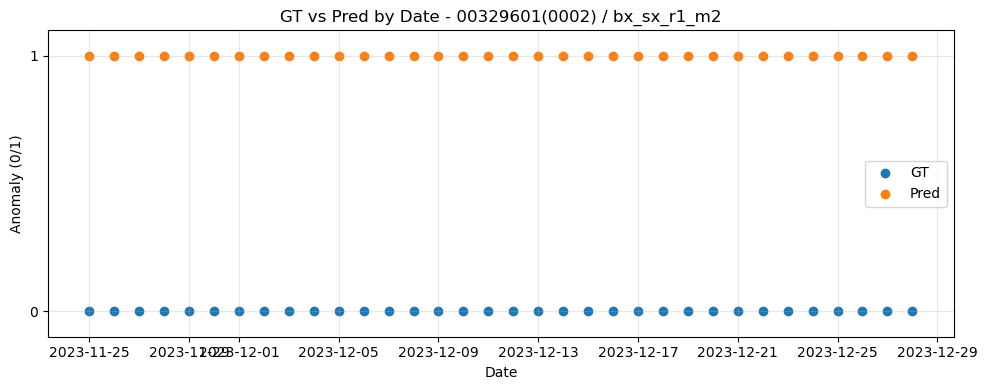

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# df 로딩 (파일에서 읽는 경우)
df = pd.read_csv("/root/ssd/yeonseo/ess/OCC_Algorithm/test_results/gmm/test_gmm_per_module_per_day.csv")

# 예시: 이미 df가 있다고 가정
# df columns: battery_id,module_folder,rack_num,module_num,date_start,n_files,score_max,score_mean,pred_anomaly,gt

import pandas as pd
import matplotlib.pyplot as plt

battery_key = "00329601(0002)"   # 원하는 배터리로 변경
module_key  = "bx_sx_r1_m2"      # 원하는 모듈로 변경

d = df[(df["battery_id"] == battery_key) & (df["module_folder"] == module_key)].copy()
d["date_start"] = pd.to_datetime(d["date_start"])

# 날짜별 여러 행이 있으면 0/1은 max 집계가 일반적
daily = (d.groupby("date_start", as_index=False)[["gt", "pred_anomaly"]]
           .max()
           .sort_values("date_start"))

plt.figure(figsize=(10, 4))
plt.scatter(daily["date_start"], daily["gt"], marker="o", label="GT")
plt.scatter(daily["date_start"], daily["pred_anomaly"], marker="o", label="Pred")

plt.yticks([0, 1])
plt.ylim(-0.1, 1.1)
plt.xlabel("Date")
plt.ylabel("Anomaly (0/1)")
plt.title(f"GT vs Pred by Date - {battery_key} / {module_key}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


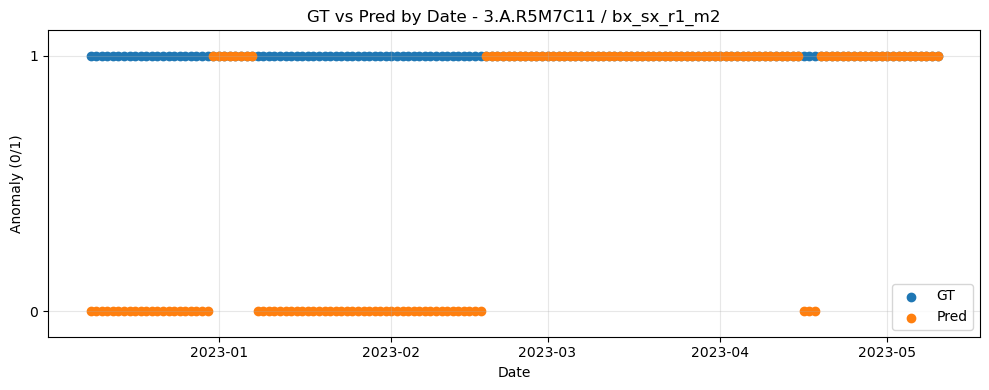

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# df 로딩 (파일에서 읽는 경우)
df = pd.read_csv("/root/ssd/yeonseo/ess/OCC_Algorithm/test_results/gmm/test_gmm_per_module_per_day.csv")

# 예시: 이미 df가 있다고 가정
# df columns: battery_id,module_folder,rack_num,module_num,date_start,n_files,score_max,score_mean,pred_anomaly,gt

import pandas as pd
import matplotlib.pyplot as plt

battery_key = "3.A.R5M7C11"   # 원하는 배터리로 변경
module_key  = "bx_sx_r1_m2"      # 원하는 모듈로 변경

d = df[(df["battery_id"] == battery_key) & (df["module_folder"] == module_key)].copy()
d["date_start"] = pd.to_datetime(d["date_start"])

# 날짜별 여러 행이 있으면 0/1은 max 집계가 일반적
daily = (d.groupby("date_start", as_index=False)[["gt", "pred_anomaly"]]
           .max()
           .sort_values("date_start"))

plt.figure(figsize=(10, 4))
plt.scatter(daily["date_start"], daily["gt"], marker="o", label="GT")
plt.scatter(daily["date_start"], daily["pred_anomaly"], marker="o", label="Pred")

plt.yticks([0, 1])
plt.ylim(-0.1, 1.1)
plt.xlabel("Date")
plt.ylabel("Anomaly (0/1)")
plt.title(f"GT vs Pred by Date - {battery_key} / {module_key}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [38]:
from pathlib import Path

root = Path("/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/final_test/normal")
count = sum(1 for p in root.glob("*/*") if p.is_dir())
print(count)


130


In [39]:
from pathlib import Path

root = Path("/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/train")
count = sum(1 for p in root.glob("*/*") if p.is_dir())
print(count)

696


In [ ]:
import pandas as pd
from io import StringIO


gmm_df = pd.read_csv("/root/ssd/yeonseo/ess/OCC_Algorithm/test_results/gmm/test_gmm_abnormal_modules_only.csv")
MoG_acc = (gmm_df["pred_anomaly"].astype(int) == gmm_df["gt"].astype(int)).mean()
print("MoG Accuracy:", MoG_acc)

iso_df = pd.read_csv("/root/ssd/yeonseo/ess/OCC_Algorithm/test_results/isoforest/test_isoforest_abnormal_modules_only.csv")
iso_acc = (iso_df["pred_anomaly"].astype(int) == iso_df["gt"].astype(int)).mean()
print("iso Accuracy:", iso_acc)

lof_df = pd.read_csv("/root/ssd/yeonseo/ess/OCC_Algorithm/test_results/lof/test_lof_abnormal_modules_only.csv")
lof_acc = (lof_df["pred_anomaly"].astype(int) == lof_df["gt"].astype(int)).mean()
print("lof Accuracy:", lof_acc)P

MoG Accuracy: 0.3953488372093023
iso Accuracy: 0.4106280193236715
lof Accuracy: 0.3953488372093023


In [ ]:
# =========================================================
# OCC + CAE Latent Anomaly Detection (iForest / LOF / GMM)
# - 바로 실행 가능한 단일 스크립트
# - 수정사항:
#   1) train에서 normal만 자동 사용 (train/normal 있으면 그걸로)
#   2) 경로 파싱(라벨/GT) robust: 마지막 normal/abnormal 기준으로 파싱
#   3) test score 계산을 anomaly_score()로 완전 통일
#   4) ROC-AUC < 0.5면 방향/파싱 경고 출력
# =========================================================

# =========================================================
# [SECTION 0] Imports
# =========================================================
import os
import re
from glob import glob
from PIL import Image

import numpy as np
import pandas as pd
import joblib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.transforms import ToTensor

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    confusion_matrix, precision_recall_fscore_support,
    roc_auc_score, average_precision_score
)

# =========================================================
# [SECTION 1] Model (CAE + encode())
# =========================================================
class ConvAutoEncoder(nn.Module):
    def __init__(self, base_ch=32):
        super(ConvAutoEncoder, self).__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(3, base_ch, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(base_ch, base_ch * 2, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 2, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(base_ch * 2, base_ch * 4, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 4, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
        )
        self.enc4 = nn.Sequential(
            nn.Conv2d(base_ch * 4, base_ch * 8, 3, stride=2, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 8, base_ch * 8, 3, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
        )

        self.bottleneck = nn.Sequential(
            nn.Conv2d(base_ch * 8, base_ch * 8, 3, padding=1),
            nn.BatchNorm2d(base_ch * 8),
            nn.ReLU(inplace=True),
        )

        self.up4 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec4 = nn.Sequential(
            nn.Conv2d(base_ch * 8 + base_ch * 8, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 4, base_ch * 4, 3, padding=1),
            nn.BatchNorm2d(base_ch * 4),
            nn.ReLU(inplace=True),
        )

        self.up3 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec3 = nn.Sequential(
            nn.Conv2d(base_ch * 4 + base_ch * 4, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch * 2, base_ch * 2, 3, padding=1),
            nn.BatchNorm2d(base_ch * 2),
            nn.ReLU(inplace=True),
        )

        self.up2 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec2 = nn.Sequential(
            nn.Conv2d(base_ch * 2 + base_ch * 2, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
        )

        self.up1 = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec1 = nn.Sequential(
            nn.Conv2d(base_ch + base_ch, base_ch, 3, padding=1),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_ch, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h, w = x.shape[-2], x.shape[-1]
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        b = self.bottleneck(e4)

        d4 = self.up4(b)
        if d4.shape[-2:] != e4.shape[-2:]:
            d4 = F.interpolate(d4, size=e4.shape[-2:], mode="bilinear", align_corners=False)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        if d3.shape[-2:] != e3.shape[-2:]:
            d3 = F.interpolate(d3, size=e3.shape[-2:], mode="bilinear", align_corners=False)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        if d2.shape[-2:] != e2.shape[-2:]:
            d2 = F.interpolate(d2, size=e2.shape[-2:], mode="bilinear", align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        if d1.shape[-2:] != e1.shape[-2:]:
            d1 = F.interpolate(d1, size=e1.shape[-2:], mode="bilinear", align_corners=False)
        out = self.dec1(torch.cat([d1, e1], dim=1))

        if out.shape[-2:] != (h, w):
            out = F.interpolate(out, size=(h, w), mode="bilinear", align_corners=False)

        return out

    @torch.no_grad()
    def encode(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        b = self.bottleneck(e4)
        z = b.mean(dim=(2, 3))
        return z


# =========================================================
# [SECTION 2] Dataset
# =========================================================
class ImgDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = glob(os.path.join(root_dir, "**", "*.png"), recursive=True)
        self.image_paths.sort()
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, img_path


# =========================================================
# [SECTION 3] Path meta (robust)
# =========================================================
def parse_meta_any(path: str) -> dict:
    """
    경로 어디에 있든 마지막으로 등장하는 normal/abnormal을 label로 잡음.
    (폴더 깊이가 바뀌어도 gt 뒤집힘 방지)
    """
    p = os.path.normpath(path)
    parts = p.split(os.sep)

    date_start = os.path.splitext(os.path.basename(p))[0]

    label_idx = None
    for i in range(len(parts) - 1):
        if parts[i] in ("normal", "abnormal"):
            label_idx = i

    label = parts[label_idx] if label_idx is not None else None
    gt = 0 if label == "normal" else 1 if label == "abnormal" else None

    battery_id = None
    module_folder = None
    if label_idx is not None:
        if label_idx + 1 < len(parts):
            battery_id = parts[label_idx + 1]
        if label_idx + 2 < len(parts):
            module_folder = parts[label_idx + 2]
    else:
        battery_id = parts[-3] if len(parts) >= 3 else None
        module_folder = parts[-2] if len(parts) >= 2 else None

    rack_num, module_num = None, None
    if module_folder:
        m = re.search(r"r(\d+)_m(\d+)", module_folder)
        if m:
            rack_num = int(m.group(1))
            module_num = int(m.group(2))

    return {
        "battery_id": battery_id,
        "module_folder": module_folder,
        "rack_num": rack_num,
        "module_num": module_num,
        "date_start": date_start,
        "gt": gt,
        "label": label,
    }


def resolve_train_root(train_root: str) -> str:
    """
    train/normal 구조면 무조건 normal만 OCC 학습에 사용 (중요!)
    """
    cand = os.path.join(train_root, "normal")
    if os.path.isdir(cand):
        return cand
    return train_root


# =========================================================
# [SECTION 4] Latent / table
# =========================================================
@torch.no_grad()
def extract_latents(model, loader, device):
    model.eval()
    zs = []
    for x, _paths in loader:
        x = x.to(device)
        z = model.encode(x).detach().cpu().numpy()
        zs.append(z)
    if len(zs) == 0:
        return np.zeros((0, 1), dtype=np.float64)
    return np.concatenate(zs, axis=0).astype(np.float64)


@torch.no_grad()
def extract_scores_table(loader, scores: np.ndarray) -> pd.DataFrame:
    rows = []
    idx = 0
    for _x, paths in loader:
        b = len(paths)
        for i in range(b):
            p = paths[i]
            meta = parse_meta_any(p)
            rows.append({
                "date": meta["date_start"],
                "path": p,
                "score": float(scores[idx + i]),
                "gt": int(meta["gt"]) if meta["gt"] is not None else None,
                "battery_id": meta["battery_id"],
                "module_folder": meta["module_folder"],
                "rack_num": meta["rack_num"],
                "module_num": meta["module_num"],
                "label": meta["label"],
            })
        idx += b
    return pd.DataFrame(rows)


# =========================================================
# [SECTION 5] OCC
# =========================================================
def make_occ(occ_type: str, seed=777, params=None):
    params = params or {}

    if occ_type == "isoforest":
        return IsolationForest(random_state=seed, n_jobs=-1, **params)

    if occ_type == "lof":
        # novelty=True: train에 fit 후 test에 out-of-sample 점수 가능
        return LocalOutlierFactor(novelty=True, n_jobs=-1, **params)

    if occ_type == "gmm":
        safe_defaults = dict(
            n_components=4,
            covariance_type="diag",
            reg_covar=1e-4,
            n_init=5,
            max_iter=500,
            random_state=seed
        )
        safe_defaults.update(params)
        return GaussianMixture(**safe_defaults)

    raise ValueError("occ_type must be one of: isoforest, lof, gmm")


def anomaly_score(occ_model, X_scaled, occ_type: str):
    """
    모든 모델 공통: score가 클수록 anomaly (양의 클래스=이상)
    """
    if occ_type == "isoforest":
        # score_samples: 클수록 정상 -> 부호 반전
        return (-occ_model.score_samples(X_scaled)).ravel()

    if occ_type == "lof":
        # decision_function: 클수록 정상 -> 부호 반전
        return (-occ_model.decision_function(X_scaled)).ravel()

    if occ_type == "gmm":
        # score_samples(loglik): 클수록 정상 -> 부호 반전
        return (-occ_model.score_samples(X_scaled)).ravel()

    raise ValueError("occ_type must be one of: isoforest, lof, gmm")


def pick_threshold_by_f1(scores_normal, scores_abnormal):
    sn = np.asarray(scores_normal).ravel()
    sa = np.asarray(scores_abnormal).ravel()

    y = np.concatenate([np.zeros_like(sn), np.ones_like(sa)])
    s = np.concatenate([sn, sa])

    cand = np.unique(s)
    if len(cand) > 2000:
        cand = np.quantile(s, np.linspace(0, 1, 2000))

    best_thr, best_f1 = float(cand[0]), -1.0
    for thr in cand:
        pred = (s >= thr).astype(int)
        tp = np.sum((pred == 1) & (y == 1))
        fp = np.sum((pred == 1) & (y == 0))
        fn = np.sum((pred == 0) & (y == 1))
        if tp == 0:
            f1 = 0.0
        else:
            precision = tp / (tp + fp + 1e-12)
            recall = tp / (tp + fn + 1e-12)
            f1 = 2 * precision * recall / (precision + recall + 1e-12)
        if f1 > best_f1:
            best_f1, best_thr = f1, float(thr)

    return best_thr, best_f1


def fit_gmm_with_fallback(gmm: GaussianMixture, X: np.ndarray):
    last_err = None
    K = int(getattr(gmm, "n_components", 1))
    candidates = sorted(set([K, max(1, K // 2), 1]), reverse=True)

    for k in candidates:
        try:
            gmm_try = GaussianMixture(
                n_components=k,
                covariance_type=gmm.covariance_type,
                reg_covar=gmm.reg_covar,
                random_state=getattr(gmm, "random_state", None),
                n_init=getattr(gmm, "n_init", 1),
                max_iter=getattr(gmm, "max_iter", 100),
                init_params=getattr(gmm, "init_params", "kmeans")
            )
            gmm_try.fit(X)
            return gmm_try
        except ValueError as e:
            last_err = e

    raise last_err


# =========================================================
# [SECTION 6] Save artifacts
# =========================================================
def save_artifacts(out_dir, ae_model, scaler, occ_model, threshold):
    os.makedirs(out_dir, exist_ok=True)

    torch.save(ae_model.state_dict(), os.path.join(out_dir, "best_ae.pth"))
    joblib.dump(scaler, os.path.join(out_dir, "latent_scaler.joblib"))
    joblib.dump(occ_model, os.path.join(out_dir, "occ_model.joblib"))
    joblib.dump(float(threshold), os.path.join(out_dir, "threshold.joblib"))

    print("\n=== Saved artifacts ===")
    print("AE         :", os.path.join(out_dir, "best_ae.pth"))
    print("Scaler     :", os.path.join(out_dir, "latent_scaler.joblib"))
    print("OCC model  :", os.path.join(out_dir, "occ_model.joblib"))
    print("Threshold  :", os.path.join(out_dir, "threshold.joblib"))


# =========================================================
# [SECTION 7] TEST helpers
# =========================================================
def build_test_loader(test_root: str, batch_size: int = 64):
    transform = ToTensor()

    roots = []
    if os.path.isdir(os.path.join(test_root, "normal")):
        roots.append(os.path.join(test_root, "normal"))
    if os.path.isdir(os.path.join(test_root, "abnormal")):
        roots.append(os.path.join(test_root, "abnormal"))
    if len(roots) == 0:
        roots = [test_root]

    datasets = [ImgDataset(r, transform=transform) for r in roots]
    if len(datasets) == 1:
        test_ds = datasets[0]
    else:
        from torch.utils.data import ConcatDataset
        test_ds = ConcatDataset(datasets)

    print("[TEST] roots:", roots)
    print("[TEST] images found:", len(test_ds))
    if len(test_ds) == 0:
        raise RuntimeError(f"No test images found. Check TEST_ROOT={test_root} and folder structure.")

    return DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=4, pin_memory=True
    )


def predict_test(test_root, model_path, occ_type, base_ch, device, out_dir, batch_size=64):
    os.makedirs(out_dir, exist_ok=True)

    ae_ckpt = os.path.join(model_path, "best_ae.pth")
    scaler = joblib.load(os.path.join(model_path, "latent_scaler.joblib"))
    occ = joblib.load(os.path.join(model_path, "occ_model.joblib"))
    threshold = float(joblib.load(os.path.join(model_path, "threshold.joblib")))

    model = ConvAutoEncoder(base_ch=base_ch).to(device)
    model.load_state_dict(torch.load(ae_ckpt, map_location=device))
    model.eval()

    test_loader = build_test_loader(test_root, batch_size=batch_size)

    rows = []
    with torch.no_grad():
        for x, paths in test_loader:
            x = x.to(device)
            z = model.encode(x).detach().cpu().numpy().astype(np.float64)
            z_s = scaler.transform(z).astype(np.float64)

            scores = anomaly_score(occ, z_s, occ_type)

            for i, p in enumerate(paths):
                meta = parse_meta_any(p)
                rows.append({"path": p, "score": float(scores[i]), **meta})

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError("Prediction DF is empty. (No rows) Check dataset loading.")

    df["pred_anomaly"] = (df["score"] >= threshold).astype(int)

    per_file_csv = os.path.join(out_dir, f"test_{occ_type}_per_file.csv")
    df.to_csv(per_file_csv, index=False)
    print("Saved:", per_file_csv)

    return df, threshold


def evaluate_test(df: pd.DataFrame):
    if df["gt"].isna().all():
        print("\n[WARN] test에 gt(normal/abnormal)가 없어서 성능 평가를 스킵합니다.")
        return None

    eval_df = df.dropna(subset=["gt"]).copy()
    y_true = eval_df["gt"].astype(int).values
    y_pred = eval_df["pred_anomaly"].astype(int).values
    y_score = eval_df["score"].astype(float).values

    roc = roc_auc_score(y_true, y_score)
    if roc < 0.5:
        print(f"[WARN] ROC-AUC < 0.5 ({roc:.4f}). score 방향/gt 파싱을 의심하세요. (score에 -1 곱하면 AUC가 {1-roc:.4f}일 수 있음)")

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    ap = average_precision_score(y_true, y_score)

    print("\n=== TEST METRICS (per-file) ===")
    print("Confusion Matrix [ [TN FP] [FN TP] ]")
    print(cm)
    print(f"Precision : {p:.4f}")
    print(f"Recall    : {r:.4f}")
    print(f"F1        : {f1:.4f}")
    print(f"ROC-AUC   : {roc:.4f}")
    print(f"PR-AUC(AP): {ap:.4f}")

    return {"cm": cm, "precision": p, "recall": r, "f1": f1, "roc_auc": roc, "ap": ap}


def aggregate_and_save(df: pd.DataFrame, out_dir: str, occ_type: str):
    # module-day
    agg1 = dict(
        n_files=("path", "count"),
        score_max=("score", "max"),
        score_mean=("score", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
    )
    if df["gt"].notna().any():
        agg1["gt"] = ("gt", "max")

    df_module_day = df.groupby(
        ["battery_id", "module_folder", "rack_num", "module_num", "date_start"],
        as_index=False
    ).agg(**agg1).sort_values(
        ["battery_id", "rack_num", "module_num", "date_start"]
    ).reset_index(drop=True)

    per_module_day_csv = os.path.join(out_dir, f"test_{occ_type}_per_module_per_day.csv")
    df_module_day.to_csv(per_module_day_csv, index=False)
    print("Saved:", per_module_day_csv)

    # module
    agg2 = dict(
        n_days=("date_start", "count"),
        abnormal_days=("pred_anomaly", "sum"),
        score_max=("score_max", "max"),
        score_mean=("score_mean", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
    )
    if "gt" in df_module_day.columns and df_module_day["gt"].notna().any():
        agg2["gt"] = ("gt", "max")

    df_module = df_module_day.groupby(
        ["battery_id", "module_folder", "rack_num", "module_num"],
        as_index=False
    ).agg(**agg2).sort_values(
        ["pred_anomaly", "score_max"], ascending=[False, False]
    ).reset_index(drop=True)

    per_module_csv = os.path.join(out_dir, f"test_{occ_type}_per_module.csv")
    df_module.to_csv(per_module_csv, index=False)
    print("Saved:", per_module_csv)

    # battery
    agg3 = dict(
        n_modules=("module_folder", "nunique"),
        abnormal_modules=("pred_anomaly", "sum"),
        score_max=("score_max", "max"),
        score_mean=("score_mean", "mean"),
        pred_anomaly=("pred_anomaly", "max"),
    )
    if "gt" in df_module.columns and df_module["gt"].notna().any():
        agg3["gt"] = ("gt", "max")

    df_battery = df_module.groupby(["battery_id"], as_index=False).agg(**agg3).sort_values(
        ["pred_anomaly", "abnormal_modules", "score_max"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    per_battery_csv = os.path.join(out_dir, f"test_{occ_type}_per_battery.csv")
    df_battery.to_csv(per_battery_csv, index=False)
    print("Saved:", per_battery_csv)

    abnormal_modules = df_module[df_module["pred_anomaly"] == 1].copy()
    abnormal_module_csv = os.path.join(out_dir, f"test_{occ_type}_abnormal_modules_only.csv")
    abnormal_modules.to_csv(abnormal_module_csv, index=False)
    print("Saved:", abnormal_module_csv)

    return df_module_day, df_module, df_battery


# =========================================================
# [SECTION 8] Main
# =========================================================
if __name__ == "__main__":

    # -----------------------------
    # [A] 공통 설정
    # -----------------------------
    SEED = 777
    BASE_CH = 48
    VAL_BATCH_SIZE = 64

    os.environ["CUDA_VISIBLE_DEVICES"] = "1"
    device = "cuda" if torch.cuda.is_available() else "cpu"

    torch.manual_seed(SEED)
    np.random.seed(SEED)
    if device == "cuda":
        torch.cuda.manual_seed_all(SEED)

    # -----------------------------
    # [B] 경로 설정 (여기만 네 환경에 맞게)
    # -----------------------------
    train_root = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/train"
    val_normal_root = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/val/normal"
    val_abnormal_root = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/val/abnormal"
    test_root = "/root/hdd/yeonseo/ess/8_drop_frequency(3.3)/final_test"  # 안에 normal/abnormal 있으면 자동 처리

    # AE ckpt (학습된 AE)
    best_ae_path = "/root/ssd/yeonseo/ess/OCC_Algorithm/model/Conv_bottleneck/epoch_30.pth"

    # OCC 종류: "isoforest" / "lof" / "gmm"
    OCC_TYPE = "gmm"

    # artifacts 저장/로드 폴더
    model_path = f"/root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC_score/{OCC_TYPE}"
    os.makedirs(model_path, exist_ok=True)

    # test 결과 저장 폴더
    out_test_dir = f"/root/ssd/yeonseo/ess/OCC_Algorithm/Conv_bottleneck_OCC_score/test_results/{OCC_TYPE}"
    os.makedirs(out_test_dir, exist_ok=True)

    # -----------------------------
    # [C] OCC 파라미터
    # -----------------------------
    OCC_PARAMS = {}
    if OCC_TYPE == "gmm":
        OCC_PARAMS = {
            "n_components": 4,
            "covariance_type": "diag",
            "reg_covar": 1e-4,  # 필요시 1e-3
            "n_init": 5,
            "max_iter": 500,
        }
    elif OCC_TYPE == "lof":
        OCC_PARAMS = {
            "n_neighbors": 20,   # 필요시 튜닝
            "metric": "minkowski",
            "p": 2
        }
    elif OCC_TYPE == "isoforest":
        OCC_PARAMS = {
            "n_estimators": 200,
            "contamination": "auto"
        }

    # -----------------------------
    # [D] VAL 기반 artifacts 만들기
    # -----------------------------
    DO_VAL_FIT = True  # artifacts 이미 있으면 False로 바꾸고 TEST만 실행해도 됨

    if DO_VAL_FIT:
        transform = ToTensor()

        # ✅ train/normal 있으면 그걸로 강제 (abnormal 섞임 방지)
        train_root_resolved = resolve_train_root(train_root)
        if train_root_resolved != train_root:
            print(f"[INFO] Using train normal only: {train_root_resolved}")
        else:
            print(f"[INFO] Using train root: {train_root_resolved}")

        train_ds = ImgDataset(root_dir=train_root_resolved, transform=transform)
        val_normal_ds = ImgDataset(root_dir=val_normal_root, transform=transform)
        val_abnormal_ds = ImgDataset(root_dir=val_abnormal_root, transform=transform)

        print("train images:", len(train_ds))
        print("val normal images:", len(val_normal_ds))
        print("val abnormal images:", len(val_abnormal_ds))

        if len(train_ds) == 0 or len(val_normal_ds) == 0 or len(val_abnormal_ds) == 0:
            raise RuntimeError("Train/Val dataset is empty. Check folder paths and glob pattern.")

        train_loader = DataLoader(train_ds, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
        vn_loader = DataLoader(val_normal_ds, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
        va_loader = DataLoader(val_abnormal_ds, batch_size=VAL_BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

        # AE load
        model = ConvAutoEncoder(base_ch=BASE_CH).to(device)
        model.load_state_dict(torch.load(best_ae_path, map_location=device))
        model.eval()
        print("\nLoaded AE:", best_ae_path)

        # latents
        Z_tr = extract_latents(model, train_loader, device)
        Z_vn = extract_latents(model, vn_loader, device)
        Z_va = extract_latents(model, va_loader, device)
        print("latent shapes:", Z_tr.shape, Z_vn.shape, Z_va.shape)

        # scaling
        scaler = StandardScaler()
        Z_tr_s = scaler.fit_transform(Z_tr).astype(np.float64)
        Z_vn_s = scaler.transform(Z_vn).astype(np.float64)
        Z_va_s = scaler.transform(Z_va).astype(np.float64)

        # OCC fit (train은 정상만!)
        occ = make_occ(OCC_TYPE, seed=SEED, params=OCC_PARAMS)
        if OCC_TYPE == "gmm":
            occ = fit_gmm_with_fallback(occ, Z_tr_s)
            print(f"[GMM FIT OK] n_components={occ.n_components}, cov={occ.covariance_type}, reg_covar={occ.reg_covar}")
        else:
            occ.fit(Z_tr_s)

        # val anomaly scores
        s_vn = anomaly_score(occ, Z_vn_s, OCC_TYPE)
        s_va = anomaly_score(occ, Z_va_s, OCC_TYPE)

        # threshold by val best F1
        threshold, best_f1 = pick_threshold_by_f1(s_vn, s_va)
        print(f"\n[{OCC_TYPE}] threshold={threshold:.6f} (val best F1={best_f1:.4f})")

        # save artifacts
        save_artifacts(model_path, model, scaler, occ, threshold)

        # save val per-file csv
        df_vn = extract_scores_table(vn_loader, s_vn)
        df_va = extract_scores_table(va_loader, s_va)
        df_val = pd.concat([df_vn, df_va], axis=0).reset_index(drop=True)
        df_val["pred_anomaly"] = (df_val["score"] >= threshold).astype(int)
        out_csv = os.path.join(model_path, f"occ_{OCC_TYPE}_per_file.csv")
        df_val.to_csv(out_csv, index=False)
        print("Saved val per-file csv:", out_csv)

    # -----------------------------
    # [E] TEST 예측 + 성능평가 + 집계
    # -----------------------------
    df_test, thr = predict_test(
        test_root=test_root,
        model_path=model_path,
        occ_type=OCC_TYPE,
        base_ch=BASE_CH,
        device=device,
        out_dir=out_test_dir,
        batch_size=64
    )

    _ = evaluate_test(df_test)
    _ = aggregate_and_save(df_test, out_test_dir, OCC_TYPE)
